In [1]:
import torch
import torch.nn as nn
from torch.optim import AdamW, Adam
from torch.nn import CrossEntropyLoss
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import StepLR,OneCycleLR
#!pip install accelerate -U

In [2]:
import numpy as np
import pandas as pd
import re
import os
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [3]:
#!pip install transformers==4.50.0
#!pip install SentencePiece
#!pip install git+https://github.com/PytorchLightning/pytorch-lightning.git@master --upgrade
#!pip install datasets
#from datasets import Dataset

In [4]:
#import pytorch_lightning as pl
import transformers
#from transformers import AlbertModel , AlbertTokenizerFast, AlbertTokenizer

In [5]:
def create_parent_dir():
    '''
    Creates parent directory structures and return their values
    '''
    data_path = './content'
    archive_path = data_path + '/data/'
    if not os.path.exists(data_path):
        print(f"Did not find {data_path} directory, creating one...")
        os.mkdir(data_path)
        os.mkdir(archive_path)
    elif not os.path.exists(archive_path):
        os.mkdir(archive_path)
    else:
        print("Required Parent Directory structure already in place")
    return data_path,archive_path

In [6]:
create_parent_dir()

Required Parent Directory structure already in place


('./content', './content/data/')

In [7]:
!wget https://lp-prod-resources.s3.amazonaws.com/610/65202/2021-06-16-14-59-22/Khilnani_LP_real_news.csv

--2026-06-04 05:28:11--  https://lp-prod-resources.s3.amazonaws.com/610/65202/2021-06-16-14-59-22/Khilnani_LP_real_news.csv
Resolving lp-prod-resources.s3.amazonaws.com (lp-prod-resources.s3.amazonaws.com)... 52.92.233.217, 3.5.82.0, 52.92.243.153, ...
Connecting to lp-prod-resources.s3.amazonaws.com (lp-prod-resources.s3.amazonaws.com)|52.92.233.217|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 53582940 (51M) [application/octet-stream]
Saving to: ‘Khilnani_LP_real_news.csv.3’

Khilnani_LP_real_ne 100%[===================>]  51.10M  42.8MB/s    in 1.2s    

2026-06-04 05:28:13 (42.8 MB/s) - ‘Khilnani_LP_real_news.csv.3’ saved [53582940/53582940]



In [8]:
!wget https://lp-prod-resources.s3.amazonaws.com/610/65202/2021-06-16-14-59-42/Khilnani_LP_fake_news.csv

--2026-06-04 05:28:13--  https://lp-prod-resources.s3.amazonaws.com/610/65202/2021-06-16-14-59-42/Khilnani_LP_fake_news.csv
Resolving lp-prod-resources.s3.amazonaws.com (lp-prod-resources.s3.amazonaws.com)... 52.92.201.81, 52.92.242.97, 52.92.243.153, ...
Connecting to lp-prod-resources.s3.amazonaws.com (lp-prod-resources.s3.amazonaws.com)|52.92.201.81|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 62789876 (60M) [application/octet-stream]
Saving to: ‘Khilnani_LP_fake_news.csv.3’

Khilnani_LP_fake_ne 100%[===================>]  59.88M  29.9MB/s    in 2.0s    

2026-06-04 05:28:15 (29.9 MB/s) - ‘Khilnani_LP_fake_news.csv.3’ saved [62789876/62789876]



In [9]:
!ls -lL

total 917812
-rwxr--r-- 1 shaheerfardan shaheerfardan    350166 Jun  3 04:40  FAKENEWS_submission.ipynb
-rwxr--r-- 1 shaheerfardan shaheerfardan    315941 Jun  2 17:54  HateSpeechDetector_v5_2L_CLSONLY_classifier_BEST.ipynb
-rw-r--r-- 1 shaheerfardan shaheerfardan   1709134 Jun  4 04:37 'Instruct_Reasoning-exp5_tested (3).ipynb'
-rwxr--r-- 1 shaheerfardan shaheerfardan  62789876 Jun 16  2021  Khilnani_LP_fake_news.csv
-rwxr--r-- 1 shaheerfardan shaheerfardan  62789876 Jun 16  2021  Khilnani_LP_fake_news.csv.1
-rw-r--r-- 1 shaheerfardan shaheerfardan  62789876 Jun 16  2021  Khilnani_LP_fake_news.csv.2
-rw-r--r-- 1 shaheerfardan shaheerfardan  62789876 Jun 16  2021  Khilnani_LP_fake_news.csv.3
-rwxr--r-- 1 shaheerfardan shaheerfardan  53582940 Jun 16  2021  Khilnani_LP_real_news.csv
-rwxr--r-- 1 shaheerfardan shaheerfardan  53582940 Jun 16  2021  Khilnani_LP_real_news.csv.1
-rw-r--r-- 1 shaheerfardan shaheerfardan  53582940 Jun 16  2021  Khilnani_LP_real_news.csv.2
-rw-r--r-- 1 shaheerfa

In [10]:
with open("./Khilnani_LP_fake_news.csv", "r") as f:
  i = 0
  for line in f.readlines():
    print(line)
    i += 1
    if i > 2:
      break

title,text,subject,date

 Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing,"Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year,  President Angry Pants tweeted.  2018 will be a great year for America! As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year. 2018 will be a great year for America!  Donald J. Trump (@realDonaldTrump) December 31, 2017Trump s tweet went down about as welll as you d expect.What kind of president sends a New Y

In [11]:
with open("./Khilnani_LP_real_news.csv", "r") as f:
  i = 0
  for line in f.readlines():
    print(line)
    i += 1
    if i > 2:
      break

title,text,subject,date

"As U.S. budget fight looms, Republicans flip their fiscal script","WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national debt to pay for tax cuts, called himself a “fiscal conservative” on Sunday and urged budget restraint in 2018. In keeping with a sharp pivot under way among Republicans, U.S. Representative Mark Meadows, speaking on CBS’ “Face the Nation,” drew a hard line on federal spending, which lawmakers are bracing to do battle over in January. When they return from the holidays on Wednesday, lawmakers will begin trying to pass a federal budget in a fight likely to be linked to other issues, such as immigration policy, even as the November congressional election campaigns approach in which Republicans will seek to keep control of Congress. President Donald Trump and his Republicans want a big budget increase in military spending, while Democrats also want pro

In [12]:
!ls -l

total 917816
-rwxr--r-- 1 shaheerfardan shaheerfardan    350166 Jun  3 04:40  FAKENEWS_submission.ipynb
-rwxr--r-- 1 shaheerfardan shaheerfardan    315941 Jun  2 17:54  HateSpeechDetector_v5_2L_CLSONLY_classifier_BEST.ipynb
-rw-r--r-- 1 shaheerfardan shaheerfardan   1709134 Jun  4 04:37 'Instruct_Reasoning-exp5_tested (3).ipynb'
-rwxr--r-- 1 shaheerfardan shaheerfardan  62789876 Jun 16  2021  Khilnani_LP_fake_news.csv
-rwxr--r-- 1 shaheerfardan shaheerfardan  62789876 Jun 16  2021  Khilnani_LP_fake_news.csv.1
-rw-r--r-- 1 shaheerfardan shaheerfardan  62789876 Jun 16  2021  Khilnani_LP_fake_news.csv.2
-rw-r--r-- 1 shaheerfardan shaheerfardan  62789876 Jun 16  2021  Khilnani_LP_fake_news.csv.3
-rwxr--r-- 1 shaheerfardan shaheerfardan  53582940 Jun 16  2021  Khilnani_LP_real_news.csv
-rwxr--r-- 1 shaheerfardan shaheerfardan  53582940 Jun 16  2021  Khilnani_LP_real_news.csv.1
-rw-r--r-- 1 shaheerfardan shaheerfardan  53582940 Jun 16  2021  Khilnani_LP_real_news.csv.2
-rw-r--r-- 1 shaheerfa

In [13]:
fake_n = './Khilnani_LP_fake_news.csv'
real_n = './Khilnani_LP_real_news.csv'

In [14]:
fake_n, real_n

('./Khilnani_LP_fake_news.csv', './Khilnani_LP_real_news.csv')

In [15]:
df_fake = pd.read_csv(fake_n)
df_real = pd.read_csv(real_n)

In [16]:
df_fake

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"
...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016"
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016"
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016"
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016"


In [17]:
df_real

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"
...,...,...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017"
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017"
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017"
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017"


In [18]:
df_real.columns, df_fake.columns

(Index(['title', 'text', 'subject', 'date'], dtype='object'),
 Index(['title', 'text', 'subject', 'date'], dtype='object'))

In [19]:
df_real['label'] = 0
df_fake['label'] = 1

In [20]:
df_real.columns, df_fake.columns

(Index(['title', 'text', 'subject', 'date', 'label'], dtype='object'),
 Index(['title', 'text', 'subject', 'date', 'label'], dtype='object'))

In [21]:
df_news = pd.concat([df_real, df_fake], axis=0)

In [22]:
df_news

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",0
...,...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",1
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",1
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",1
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",1


In [23]:
len(df_fake)+len(df_real)

44898

In [24]:
df_news = df_news.sample(frac=1)

In [25]:
len(df_news)

44898

In [26]:
df_news

,title,text,subject,date,label
7243,A post-Trump SEC could shake up current policy,WASHINGTON (Reuters) - It will be a new day at...,politicsNews,"November 16, 2016",0
4420,Alabama governor could face charges after ethi...,(Reuters) - Alabama Governor Robert Bentley sa...,politicsNews,"April 6, 2017",0
15832,Macedonia jails 33 ethnic Albanians for 2015 s...,SKOPJE (Reuters) - A Macedonian court sentence...,worldnews,"November 2, 2017",0
19820,LEAKED EMAIL: Hillary’s Team Caught Bashing “B...,"As a Catholic, I m not sure what offends me mo...",left-news,"Oct 11, 2016",1
20602,U.S. Navy moving aircraft carrier in anticipat...,WASHINGTON (Reuters) - The U.S. Navy said on F...,worldnews,"September 8, 2017",0
...,...,...,...,...,...
10084,WATCH: DEMOCRAT STATE SENATOR Who Said She Wou...,"Last week, MO State Senator Chappelle-Nadal sa...",politics,"Aug 21, 2017",1
4303,Hypocrite Conservative ‘Christian’ Leaders ST...,Just when you thought support of Donald Trump ...,News,"October 8, 2016",1
2201,President Trump's reelection campaign releases...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"August 13, 2017",0
2742,Trump Says His Ban Isn’t A Ban And Only Keeps...,Donald Trump just got caught lying on Twitter ...,News,"February 1, 2017",1


In [27]:
df_fn = df_news[['text', 'label']]

In [28]:
df_fn

,text,label
7243,WASHINGTON (Reuters) - It will be a new day at...,0
4420,(Reuters) - Alabama Governor Robert Bentley sa...,0
15832,SKOPJE (Reuters) - A Macedonian court sentence...,0
19820,"As a Catholic, I m not sure what offends me mo...",1
20602,WASHINGTON (Reuters) - The U.S. Navy said on F...,0
...,...,...
10084,"Last week, MO State Senator Chappelle-Nadal sa...",1
4303,Just when you thought support of Donald Trump ...,1
2201,WASHINGTON (Reuters) - U.S. President Donald T...,0
2742,Donald Trump just got caught lying on Twitter ...,1


In [29]:
#!pip install nltk
import nltk

In [30]:
#!pip install tokenizers

In [31]:
from tokenizers.processors import TemplateProcessing

In [32]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /teamspace/studios/this_studio/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [33]:
df_fn['text'] = df_fn['text'].apply(lambda x: x.lower())

/tmp/ipykernel_604631/824053679.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fn['text'] = df_fn['text'].apply(lambda x: x.lower())


In [34]:
df_fn

,text,label
7243,washington (reuters) - it will be a new day at...,0
4420,(reuters) - alabama governor robert bentley sa...,0
15832,skopje (reuters) - a macedonian court sentence...,0
19820,"as a catholic, i m not sure what offends me mo...",1
20602,washington (reuters) - the u.s. navy said on f...,0
...,...,...
10084,"last week, mo state senator chappelle-nadal sa...",1
4303,just when you thought support of donald trump ...,1
2201,washington (reuters) - u.s. president donald t...,0
2742,donald trump just got caught lying on twitter ...,1


In [35]:
df_fn['text'].iloc[2]

'skopje (reuters) - a macedonian court sentenced 33 ethnic albanians to jail terms on thursday, including seven given life sentences, after they were found guilty of plotting attacks and clashing with the police in a 2015 shootout in which 22 people were killed. the 33 were accused of being part of a group of albanian gunmen involved in the may 9, 2015 shootout with police in the northern macedonian town of kumanovo, in which eight police officers were among those killed and dozens were wounded. some of the defendants were from neighboring kosovo, while others were from macedonia s own albanian minority.  the evidence offered by the prosecutor shows that the accused committed the criminal acts of terrorism and terrorist organization,  the presiding judge said.  the court was under heavy police protection, with helicopters flying overhead. the defendants protested while the verdict was being read, prompting the judge to order 33 of them to leave the courtroom before hearing sentences.  

In [36]:
stopwords = nltk.corpus.stopwords.words('english')

In [37]:
len(stopwords)

198

In [38]:
df_fn['text'] = df_fn['text'].apply(lambda x: " ".join([word for word in x.split() if word not in stopwords]))

/tmp/ipykernel_604631/1749885009.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fn['text'] = df_fn['text'].apply(lambda x: " ".join([word for word in x.split() if word not in stopwords]))


In [39]:
df_fn

,text,label
7243,washington (reuters) - new day u.s. securities...,0
4420,(reuters) - alabama governor robert bentley sa...,0
15832,skopje (reuters) - macedonian court sentenced ...,0
19820,"catholic, sure offends more, fellow catholics ...",1
20602,washington (reuters) - u.s. navy said friday m...,0
...,...,...
10084,"last week, mo state senator chappelle-nadal sa...",1
4303,thought support donald trump would drop zero t...,1
2201,washington (reuters) - u.s. president donald t...,0
2742,donald trump got caught lying twitter got tota...,1


In [40]:
df_fn['text'].iloc[2]

'skopje (reuters) - macedonian court sentenced 33 ethnic albanians jail terms thursday, including seven given life sentences, found guilty plotting attacks clashing police 2015 shootout 22 people killed. 33 accused part group albanian gunmen involved may 9, 2015 shootout police northern macedonian town kumanovo, eight police officers among killed dozens wounded. defendants neighboring kosovo, others macedonia albanian minority. evidence offered prosecutor shows accused committed criminal acts terrorism terrorist organization, presiding judge said. court heavy police protection, helicopters flying overhead. defendants protested verdict read, prompting judge order 33 leave courtroom hearing sentences. 2015 shootout occurred police raid followed attack armed men border post. former guerrillas national liberation army (nla), ethnic albanian militia fought insurgency 2001 scores people killed. nla disbanded 2002 former leaders entered government. naser raufi, one defense lawyers, said trial

In [41]:
df_fn['text'] = df_fn['text'].apply(lambda x: re.sub(r'[^\w\s]', '', x))

/tmp/ipykernel_604631/4158552898.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fn['text'] = df_fn['text'].apply(lambda x: re.sub(r'[^\w\s]', '', x))


In [42]:
df_fn

,text,label
7243,washington reuters new day us securities exch...,0
4420,reuters alabama governor robert bentley said ...,0
15832,skopje reuters macedonian court sentenced 33 ...,0
19820,catholic sure offends more fellow catholics wo...,1
20602,washington reuters us navy said friday moving...,0
...,...,...
10084,last week mo state senator chappellenadal said...,1
4303,thought support donald trump would drop zero t...,1
2201,washington reuters us president donald trumps...,0
2742,donald trump got caught lying twitter got tota...,1


In [43]:
df_fn['text'].iloc[2]

'skopje reuters  macedonian court sentenced 33 ethnic albanians jail terms thursday including seven given life sentences found guilty plotting attacks clashing police 2015 shootout 22 people killed 33 accused part group albanian gunmen involved may 9 2015 shootout police northern macedonian town kumanovo eight police officers among killed dozens wounded defendants neighboring kosovo others macedonia albanian minority evidence offered prosecutor shows accused committed criminal acts terrorism terrorist organization presiding judge said court heavy police protection helicopters flying overhead defendants protested verdict read prompting judge order 33 leave courtroom hearing sentences 2015 shootout occurred police raid followed attack armed men border post former guerrillas national liberation army nla ethnic albanian militia fought insurgency 2001 scores people killed nla disbanded 2002 former leaders entered government naser raufi one defense lawyers said trial staged expect see length

In [44]:
X_train, X_val, y_train, y_val = train_test_split(df_fn['text'], df_fn['label'], test_size=0.2, shuffle=True, random_state=42, stratify=df_fn['label'])

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.1, shuffle=True, random_state=42, stratify=y_train)

In [46]:
X_train, X_val, X_test

(17041    london reuters  britain parliament discuss key...
 17224    safe enjoy 4th homeland security wonderful pol...
 3099     meryl streep accomplished actress philanthropi...
 20437    movie hillary want america see hillary clinton...
 2579     trump still beating widespread voter fraud dru...
                                ...                        
 5953     many musical artists demanded donald trump cea...
 16969    istanbul reuters  turkish police detained prom...
 642      ever wonder donald trump insistence repealing ...
 12992    maiduguri nigeria reuters  nigeria replacing m...
 13805    mexico city reuters  mexican finance minister ...
 Name: text, Length: 32326, dtype: object,
 17076    get this previously deported mentally ill ille...
 13701    naypyitaw reuters  myanmar leader aung san suu...
 425      washington reuters  republican tax bill us sen...
 21194    mexico city reuters  venezuela former chief pr...
 4972     supreme court justice ruth bader ginsburg blas.

In [47]:
y_train, y_val, y_test

(17041    0
 17224    1
 3099     1
 20437    1
 2579     1
         ..
 5953     1
 16969    0
 642      1
 12992    0
 13805    0
 Name: label, Length: 32326, dtype: int64,
 17076    1
 13701    0
 425      0
 21194    0
 4972     1
         ..
 14380    1
 17725    1
 15028    1
 2659     1
 21119    0
 Name: label, Length: 8980, dtype: int64,
 14115    0
 9240     1
 19583    0
 9105     0
 18571    1
         ..
 13579    0
 3855     1
 11922    0
 11030    0
 6981     1
 Name: label, Length: 3592, dtype: int64)

In [48]:
len(X_train), len(X_val), len(y_train), len(y_val), len(X_test), len(y_test)

(32326, 8980, 32326, 8980, 3592, 3592)

In [49]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from transformers import PreTrainedTokenizerFast

In [50]:
df_fn['text']

7243     washington reuters  new day us securities exch...
4420     reuters  alabama governor robert bentley said ...
15832    skopje reuters  macedonian court sentenced 33 ...
19820    catholic sure offends more fellow catholics wo...
20602    washington reuters  us navy said friday moving...
                               ...                        
10084    last week mo state senator chappellenadal said...
4303     thought support donald trump would drop zero t...
2201     washington reuters  us president donald trumps...
2742     donald trump got caught lying twitter got tota...
2791     washington reuters  president donald trump sai...
Name: text, Length: 44898, dtype: object

In [51]:
!ls -l

total 917876
-rwxr--r-- 1 shaheerfardan shaheerfardan    350166 Jun  3 04:40  FAKENEWS_submission.ipynb
-rwxr--r-- 1 shaheerfardan shaheerfardan    315941 Jun  2 17:54  HateSpeechDetector_v5_2L_CLSONLY_classifier_BEST.ipynb
-rw-r--r-- 1 shaheerfardan shaheerfardan   1709134 Jun  4 04:37 'Instruct_Reasoning-exp5_tested (3).ipynb'
-rwxr--r-- 1 shaheerfardan shaheerfardan  62789876 Jun 16  2021  Khilnani_LP_fake_news.csv
-rwxr--r-- 1 shaheerfardan shaheerfardan  62789876 Jun 16  2021  Khilnani_LP_fake_news.csv.1
-rw-r--r-- 1 shaheerfardan shaheerfardan  62789876 Jun 16  2021  Khilnani_LP_fake_news.csv.2
-rw-r--r-- 1 shaheerfardan shaheerfardan  62789876 Jun 16  2021  Khilnani_LP_fake_news.csv.3
-rwxr--r-- 1 shaheerfardan shaheerfardan  53582940 Jun 16  2021  Khilnani_LP_real_news.csv
-rwxr--r-- 1 shaheerfardan shaheerfardan  53582940 Jun 16  2021  Khilnani_LP_real_news.csv.1
-rw-r--r-- 1 shaheerfardan shaheerfardan  53582940 Jun 16  2021  Khilnani_LP_real_news.csv.2
-rw-r--r-- 1 shaheerfa

In [52]:
df_fn['text'].to_csv('./token_train.csv', header=False, index=False)


In [53]:
!ls -l

total 917896
-rwxr--r-- 1 shaheerfardan shaheerfardan    350166 Jun  3 04:40  FAKENEWS_submission.ipynb
-rwxr--r-- 1 shaheerfardan shaheerfardan    315941 Jun  2 17:54  HateSpeechDetector_v5_2L_CLSONLY_classifier_BEST.ipynb
-rw-r--r-- 1 shaheerfardan shaheerfardan   1709134 Jun  4 04:37 'Instruct_Reasoning-exp5_tested (3).ipynb'
-rwxr--r-- 1 shaheerfardan shaheerfardan  62789876 Jun 16  2021  Khilnani_LP_fake_news.csv
-rwxr--r-- 1 shaheerfardan shaheerfardan  62789876 Jun 16  2021  Khilnani_LP_fake_news.csv.1
-rw-r--r-- 1 shaheerfardan shaheerfardan  62789876 Jun 16  2021  Khilnani_LP_fake_news.csv.2
-rw-r--r-- 1 shaheerfardan shaheerfardan  62789876 Jun 16  2021  Khilnani_LP_fake_news.csv.3
-rwxr--r-- 1 shaheerfardan shaheerfardan  53582940 Jun 16  2021  Khilnani_LP_real_news.csv
-rwxr--r-- 1 shaheerfardan shaheerfardan  53582940 Jun 16  2021  Khilnani_LP_real_news.csv.1
-rw-r--r-- 1 shaheerfardan shaheerfardan  53582940 Jun 16  2021  Khilnani_LP_real_news.csv.2
-rw-r--r-- 1 shaheerfa

In [54]:
list_toks = df_fn['text'].tolist()

In [55]:
len(list_toks)

44898

In [56]:
list_toks[0]

'washington reuters  new day us securities exchange commission presidentelect donald trump installs choice run agency trumps transition team already regulatoryrelief mode promising revamp doddfrank financial reform legislation rules already marked death dialback expected chopping block soon trump takes oath office proposal would require companies disclose pay ratios ceos employees another would require companies disclose whether products contain conflict minerals  minerals mined wartorn region africa dead prospect sec approving tough fiduciary rule financial advisers say policy experts trumps decision tap former republican sec commissioner paul atkins help manage trump teams transition efforts sec financial agencies offers window changes could store atkins founder regulatory consulting firm patomak global partners viewed top contender position sec chairman itself though transition head could also recommend someone else job atkins wellknown conservative views everything enforcement pena

In [57]:
with open('./datafile.txt', 'w') as f:
  for news in list_toks:
    f.write(news)

In [58]:
!ls -l

total 917896
-rwxr--r-- 1 shaheerfardan shaheerfardan    350166 Jun  3 04:40  FAKENEWS_submission.ipynb
-rwxr--r-- 1 shaheerfardan shaheerfardan    315941 Jun  2 17:54  HateSpeechDetector_v5_2L_CLSONLY_classifier_BEST.ipynb
-rw-r--r-- 1 shaheerfardan shaheerfardan   1709134 Jun  4 04:37 'Instruct_Reasoning-exp5_tested (3).ipynb'
-rwxr--r-- 1 shaheerfardan shaheerfardan  62789876 Jun 16  2021  Khilnani_LP_fake_news.csv
-rwxr--r-- 1 shaheerfardan shaheerfardan  62789876 Jun 16  2021  Khilnani_LP_fake_news.csv.1
-rw-r--r-- 1 shaheerfardan shaheerfardan  62789876 Jun 16  2021  Khilnani_LP_fake_news.csv.2
-rw-r--r-- 1 shaheerfardan shaheerfardan  62789876 Jun 16  2021  Khilnani_LP_fake_news.csv.3
-rwxr--r-- 1 shaheerfardan shaheerfardan  53582940 Jun 16  2021  Khilnani_LP_real_news.csv
-rwxr--r-- 1 shaheerfardan shaheerfardan  53582940 Jun 16  2021  Khilnani_LP_real_news.csv.1
-rw-r--r-- 1 shaheerfardan shaheerfardan  53582940 Jun 16  2021  Khilnani_LP_real_news.csv.2
-rw-r--r-- 1 shaheerfa

In [59]:
with open('./datafile_a.txt', 'a') as f:
  for news in list_toks:
    f.write(news)

In [60]:
!ls -l

total 995416
-rwxr--r-- 1 shaheerfardan shaheerfardan    350166 Jun  3 04:40  FAKENEWS_submission.ipynb
-rwxr--r-- 1 shaheerfardan shaheerfardan    315941 Jun  2 17:54  HateSpeechDetector_v5_2L_CLSONLY_classifier_BEST.ipynb
-rw-r--r-- 1 shaheerfardan shaheerfardan   1709134 Jun  4 04:37 'Instruct_Reasoning-exp5_tested (3).ipynb'
-rwxr--r-- 1 shaheerfardan shaheerfardan  62789876 Jun 16  2021  Khilnani_LP_fake_news.csv
-rwxr--r-- 1 shaheerfardan shaheerfardan  62789876 Jun 16  2021  Khilnani_LP_fake_news.csv.1
-rw-r--r-- 1 shaheerfardan shaheerfardan  62789876 Jun 16  2021  Khilnani_LP_fake_news.csv.2
-rw-r--r-- 1 shaheerfardan shaheerfardan  62789876 Jun 16  2021  Khilnani_LP_fake_news.csv.3
-rwxr--r-- 1 shaheerfardan shaheerfardan  53582940 Jun 16  2021  Khilnani_LP_real_news.csv
-rwxr--r-- 1 shaheerfardan shaheerfardan  53582940 Jun 16  2021  Khilnani_LP_real_news.csv.1
-rw-r--r-- 1 shaheerfardan shaheerfardan  53582940 Jun 16  2021  Khilnani_LP_real_news.csv.2
-rw-r--r-- 1 shaheerfa

In [61]:
special_tokens=["[UNK]","[CLS]","[SEP]","[PAD]","[MASK]"]

In [62]:
temp_proc= TemplateProcessing(
    single="[CLS] $A [SEP]",
    pair="[CLS] $A [SEP] $B:1 [SEP]:1",
    special_tokens=[
        ("[CLS]", special_tokens.index("[CLS]")),
        ("[SEP]", special_tokens.index("[SEP]")),
        ],
    )

In [63]:
from tokenizers.normalizers import (Sequence,Lowercase, NFD, StripAccents)

In [64]:
from tokenizers.decoders import BPEDecoder

In [65]:
tokenizer = Tokenizer(BPE())

In [66]:
tokenizer.normalizer = Sequence([NFD(),Lowercase(),StripAccents()])
tokenizer.pre_tokenizer = Whitespace()
tokenizer.decoder = BPEDecoder()
tokenizer.post_processor=temp_proc

In [67]:
trainer = BpeTrainer(special_tokens= special_tokens)

In [68]:
token_train_file = ['./datafile.txt']
tokenizer.train(token_train_file, trainer)

In [69]:
tokenizer

Tokenizer(version="1.0", truncation=None, padding=None, added_tokens=[{"id":0, "content":"[UNK]", "single_word":False, "lstrip":False, "rstrip":False, "normalized":False, "special":True}, {"id":1, "content":"[CLS]", "single_word":False, "lstrip":False, "rstrip":False, "normalized":False, "special":True}, {"id":2, "content":"[SEP]", "single_word":False, "lstrip":False, "rstrip":False, "normalized":False, "special":True}, {"id":3, "content":"[PAD]", "single_word":False, "lstrip":False, "rstrip":False, "normalized":False, "special":True}, {"id":4, "content":"[MASK]", "single_word":False, "lstrip":False, "rstrip":False, "normalized":False, "special":True}], normalizer=Sequence(normalizers=[NFD(), Lowercase(), StripAccents()]), pre_tokenizer=Whitespace(), post_processor=TemplateProcessing(single=[SpecialToken(id="[CLS]", type_id=0), Sequence(id=A, type_id=0), SpecialToken(id="[SEP]", type_id=0)], pair=[SpecialToken(id="[CLS]", type_id=0), Sequence(id=A, type_id=0), SpecialToken(id="[SEP]", 

In [70]:
print(f"Trained vocab size: {tokenizer.get_vocab_size()}" )

Trained vocab size: 30000


In [71]:
tokenizer.model.save('.')

['./vocab.json', './merges.txt']

In [72]:
!wc -l merges.txt

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


29958 merges.txt


In [73]:
!head -3 ./merges.txt

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


#version: 0.2
i n
e r


In [74]:
tokenizer.save("MyBPETokenizer.json")

In [75]:
!head -45 MyBPETokenizer.json

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


{
  "version": "1.0",
  "truncation": null,
  "padding": null,
  "added_tokens": [
    {
      "id": 0,
      "content": "[UNK]",
      "single_word": false,
      "lstrip": false,
      "rstrip": false,
      "normalized": false,
      "special": true
    },
    {
      "id": 1,
      "content": "[CLS]",
      "single_word": false,
      "lstrip": false,
      "rstrip": false,
      "normalized": false,
      "special": true
    },
    {
      "id": 2,
      "content": "[SEP]",
      "single_word": false,
      "lstrip": false,
      "rstrip": false,
      "normalized": false,
      "special": true
    },
    {
      "id": 3,
      "content": "[PAD]",
      "single_word": false,
      "lstrip": false,
      "rstrip": false,
      "normalized": false,
      "special": true
    },
    {
      "id": 4,
      "content": "[MASK]",
      "single_word": false,


In [76]:
tokenizerFromFile = Tokenizer.from_file("MyBPETokenizer.json")

In [77]:
sen_enc3 = tokenizerFromFile.encode("I like Hugging Face and Macbeth")
print(f"Output: {format(sen_enc3.tokens)}")

Output: ['[CLS]', 'i', 'like', 'hugging', 'face', 'and', 'mac', 'beth', '[SEP]']


In [78]:
#####

In [79]:
trained_tokenizer = PreTrainedTokenizerFast(tokenizer_object=tokenizerFromFile)

In [80]:
trained_tokenizer

PreTrainedTokenizerFast(name_or_path='', vocab_size=30000, model_max_length=1000000000000000019884624838656, is_fast=True, padding_side='right', truncation_side='right', special_tokens={}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	4: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [81]:
trained_tokenizer.add_special_tokens({'pad_token': '[PAD]'})

0

In [82]:
#trained_tokenizer.vocab

In [83]:
trained_tokenizer(X_train.iloc[0], padding='max_length', truncation=True, max_length=64)

{'input_ids': [1, 2369, 316, 1718, 1585, 1063, 966, 1352, 1347, 6789, 369, 864, 514, 921, 2239, 317, 10796, 11194, 336, 2014, 104, 782, 3414, 2016, 308, 5308, 2880, 7226, 9877, 369, 2330, 308, 2653, 2942, 915, 1971, 484, 277, 2119, 277, 526, 1718, 5802, 1913, 2498, 16339, 163, 1585, 516, 960, 1368, 2415, 2429, 2204, 369, 1415, 3933, 1368, 1616, 1362, 785, 5327, 402, 2], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [84]:
df_tokens_train = pd.DataFrame()

In [85]:
df_tokens_train['tokenized'] = X_train.apply(lambda x: trained_tokenizer(x, padding='max_length', truncation=True, max_length=64, return_tensors='pt'))

In [86]:
df_tokens_train

,tokenized
17041,"[input_ids, token_type_ids, attention_mask]"
17224,"[input_ids, token_type_ids, attention_mask]"
3099,"[input_ids, token_type_ids, attention_mask]"
20437,"[input_ids, token_type_ids, attention_mask]"
2579,"[input_ids, token_type_ids, attention_mask]"
...,...
5953,"[input_ids, token_type_ids, attention_mask]"
16969,"[input_ids, token_type_ids, attention_mask]"
642,"[input_ids, token_type_ids, attention_mask]"
12992,"[input_ids, token_type_ids, attention_mask]"


In [87]:
df_tokens_train['tokenized'].iloc[0]['input_ids'].shape

torch.Size([1, 64])

In [88]:
df_tokens_val = pd.DataFrame()

In [89]:
df_tokens_val['tokenized'] = X_val.apply(lambda x: trained_tokenizer(x, padding='max_length', truncation=True, max_length=64, return_tensors='pt'))

In [90]:
len(df_tokens_val), len(df_tokens_train)

(8980, 32326)

In [91]:
df_tokens_test = pd.DataFrame()

In [92]:
df_tokens_test['tokenized'] = X_test.apply(lambda x: trained_tokenizer(x, padding='max_length', truncation=True, max_length=64, return_tensors='pt'))

In [93]:
len(df_tokens_test), len(df_tokens_val), len(df_tokens_train)

(3592, 8980, 32326)

In [94]:
ckpt = 'roberta-base'

In [95]:
from transformers import RobertaModel

In [96]:
model = RobertaModel.from_pretrained(ckpt)
model

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RobertaModel(
  (embeddings): RobertaEmbeddings(
    (word_embeddings): Embedding(50265, 768, padding_idx=1)
    (position_embeddings): Embedding(514, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): RobertaEncoder(
    (layer): ModuleList(
      (0-11): 12 x RobertaLayer(
        (attention): RobertaAttention(
          (self): RobertaSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): RobertaSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (dr

In [97]:
model.__dict__

{'training': False,
 '_parameters': {},
 '_buffers': {},
 '_non_persistent_buffers_set': set(),
 '_backward_pre_hooks': OrderedDict(),
 '_backward_hooks': OrderedDict(),
 '_is_full_backward_hook': None,
 '_forward_hooks': OrderedDict(),
 '_forward_hooks_with_kwargs': OrderedDict(),
 '_forward_hooks_always_called': OrderedDict(),
 '_forward_pre_hooks': OrderedDict(),
 '_forward_pre_hooks_with_kwargs': OrderedDict(),
 '_state_dict_hooks': OrderedDict(),
 '_state_dict_pre_hooks': OrderedDict(),
 '_load_state_dict_pre_hooks': OrderedDict(),
 '_load_state_dict_post_hooks': OrderedDict(),
 '_modules': {'embeddings': RobertaEmbeddings(
    (word_embeddings): Embedding(50265, 768, padding_idx=1)
    (position_embeddings): Embedding(514, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  ),
  'encoder': RobertaEncoder(
    (layer): ModuleList(
      (0-11): 12 x 

In [98]:
model(**df_tokens_train['tokenized'].iloc[0]).last_hidden_state.shape #['input_ids'], df_tokens_train['tokenized'].iloc[0]['token_type_ids'],  df_tokens_train['tokenized'].iloc[0]['attention_mask'])

torch.Size([1, 64, 768])

In [99]:
input_ids = df_tokens_train['tokenized'].iloc[0]['input_ids']
attention_mask = df_tokens_train['tokenized'].iloc[0]['attention_mask']

In [100]:
input_ids, attention_mask

(tensor([[    1,  2369,   316,  1718,  1585,  1063,   966,  1352,  1347,  6789,
            369,   864,   514,   921,  2239,   317, 10796, 11194,   336,  2014,
            104,   782,  3414,  2016,   308,  5308,  2880,  7226,  9877,   369,
           2330,   308,  2653,  2942,   915,  1971,   484,   277,  2119,   277,
            526,  1718,  5802,  1913,  2498, 16339,   163,  1585,   516,   960,
           1368,  2415,  2429,  2204,   369,  1415,  3933,  1368,  1616,  1362,
            785,  5327,   402,     2]]),
 tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
          1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
          1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]))

In [101]:
t0 = df_tokens_train['tokenized'].iloc[0]['input_ids']
t1 = df_tokens_train['tokenized'].iloc[1]['input_ids']
t2 = df_tokens_train['tokenized'].iloc[2]['input_ids']
ti = torch.cat([t0, t1, t2], dim=0)

In [102]:
ti.shape

torch.Size([3, 64])

In [103]:
a0 = df_tokens_train['tokenized'].iloc[0]['attention_mask']
a1 = df_tokens_train['tokenized'].iloc[1]['attention_mask']
a2 = df_tokens_train['tokenized'].iloc[2]['attention_mask']
am = torch.cat([a0, a1, a2], dim=0)

In [104]:
am.shape

torch.Size([3, 64])

In [105]:
ti.shape, am.shape, type(ti), type(am)

(torch.Size([3, 64]), torch.Size([3, 64]), torch.Tensor, torch.Tensor)

In [106]:
model(input_ids=ti, attention_mask=am).last_hidden_state.shape

torch.Size([3, 64, 768])

In [107]:
class fakenew_ds(Dataset):
  def __init__(self, tokens, labels):
    self.tokens = tokens
    self.labels = labels

  def __getitem__(self, idx):
    input_ids = self.tokens.iloc[idx]['input_ids'].squeeze()
    token_type_ids = self.tokens.iloc[idx]['token_type_ids'].squeeze()
    attention_mask = self.tokens.iloc[idx]['attention_mask'].squeeze()
    labels = torch.tensor(self.labels.iloc[idx]) #.type(torch.LongTensor)
    return input_ids, token_type_ids, attention_mask, labels

  def __len__(self):
    return len(self.labels)

In [108]:
train_ds = fakenew_ds(df_tokens_train['tokenized'], y_train)
val_ds = fakenew_ds(df_tokens_val['tokenized'], y_val)

In [109]:
test_ds = fakenew_ds(df_tokens_test['tokenized'], y_test)

In [110]:
len(train_ds), len(val_ds), len(test_ds)

(32326, 8980, 3592)

In [111]:
train_ds[0], val_ds[0]

((tensor([    1,  2369,   316,  1718,  1585,  1063,   966,  1352,  1347,  6789,
            369,   864,   514,   921,  2239,   317, 10796, 11194,   336,  2014,
            104,   782,  3414,  2016,   308,  5308,  2880,  7226,  9877,   369,
           2330,   308,  2653,  2942,   915,  1971,   484,   277,  2119,   277,
            526,  1718,  5802,  1913,  2498, 16339,   163,  1585,   516,   960,
           1368,  2415,  2429,  2204,   369,  1415,  3933,  1368,  1616,  1362,
            785,  5327,   402,     2]),
  tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
          0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
          0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
          1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
          1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
  tensor(0)),
 (tensor([    1,  

In [112]:
os.cpu_count()

8

In [113]:
batch_size=32
train_dl = DataLoader(train_ds, shuffle=True, num_workers=os.cpu_count(), batch_size=batch_size)
valid_dl = DataLoader(val_ds, shuffle=False, num_workers=os.cpu_count(), batch_size=batch_size)

In [114]:
test_dl = DataLoader(test_ds, shuffle=False, num_workers=os.cpu_count(), batch_size=batch_size)

In [115]:
len(train_dl), len(valid_dl), len(train_ds)/32, len(val_ds)/32, len(test_ds)/32, len(test_dl)

(1011, 281, 1010.1875, 280.625, 112.25, 113)

In [116]:
input_tokens, token_type_ids, attention_tokens , labels = next(iter(train_dl))

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

In [117]:
input_tokens.shape, token_type_ids.shape, attention_tokens.shape, labels.shape

(torch.Size([32, 64]),
 torch.Size([32, 64]),
 torch.Size([32, 64]),
 torch.Size([32]))

In [118]:
model(input_ids=input_tokens, attention_mask=attention_tokens).last_hidden_state.shape

torch.Size([32, 64, 768])

In [119]:
model(input_tokens, attention_mask=attention_tokens).last_hidden_state.shape

torch.Size([32, 64, 768])

In [120]:
class custom_roberta(torch.nn.Module):
  def __init__(self, embed_size, ckpt, num_labels):
    super().__init__()

    self.checkpoint = ckpt
    self.basemodel = RobertaModel.from_pretrained(self.checkpoint)
    self.flatten = nn.Flatten()
    self.classifier = nn.Sequential(
        nn.Linear(embed_size, embed_size, bias=False),
        nn.BatchNorm1d(embed_size),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Linear(embed_size, num_labels)
    )

  def forward(self, input_tokens, attention_tokens):

    x = self.basemodel(input_tokens, attention_mask=attention_tokens)
    x = self.flatten(x.last_hidden_state[:,0,:])
    x = self.classifier(x)

    return x

In [121]:
embed_size = 768
ckpt = 'roberta-base'
num_labels = 2
model = custom_roberta(embed_size,ckpt,num_labels)

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [122]:
model

custom_roberta(
  (basemodel): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm)

In [123]:
model(input_tokens, attention_tokens)

tensor([[-0.4313, -0.4308],
        [ 0.1284, -0.6646],
        [-0.3625, -0.7422],
        [-0.2735, -0.3362],
        [-0.3634,  0.0181],
        [ 0.7025,  0.1277],
        [-0.5746, -0.6595],
        [ 1.0602, -1.2536],
        [-0.5002, -0.7761],
        [-0.4000, -0.8954],
        [-0.0176, -0.4847],
        [ 0.3926,  0.2696],
        [ 0.1342, -0.2913],
        [ 0.0812,  0.3420],
        [-0.7553, -0.8730],
        [-1.2408, -0.2452],
        [ 0.0742, -1.9062],
        [-0.3144, -0.6468],
        [ 1.8319, -0.6760],
        [-0.6135, -0.2271],
        [-0.0021, -0.6607],
        [-0.0825,  0.0123],
        [ 1.2877, -0.0840],
        [-0.6496, -0.1440],
        [ 0.5173, -1.5152],
        [ 0.0249, -0.9798],
        [ 0.1894, -0.7678],
        [-0.3236, -0.8244],
        [-0.1387, -0.2401],
        [-0.4635,  0.1170],
        [-0.7107,  0.2220],
        [ 0.3499, -0.9052]], grad_fn=<AddmmBackward0>)

In [124]:
model(input_tokens, attention_tokens).shape

torch.Size([32, 2])

In [125]:
class Training():
    def __init__(self, model, optimizer, loss_fn, epochs, batch_size, train_gen, valid_gen, test_gen,
                len_train_ds, len_valid_ds, len_test_ds, device, labels_cat, oclr_sched=None, oclr=False, early_stop=True, patience=4):
        super().__init__()
        self.model = model.to(device)
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.epochs = epochs
        self.batch_size = batch_size
        self.train_generator = train_gen
        self.valid_generator = valid_gen
        self.test_generator = test_gen
        self.train_ds_size = len_train_ds
        self.valid_ds_size = len_valid_ds
        self.test_ds_size = len_test_ds
        self.train_history = {'loss': [], 'accuracy': [], 'f1': [], 'precision': [], 'recall': []}
        self.valid_history = {'loss': [], 'accuracy': [], 'f1': [], 'precision': [], 'recall': [], 'ckpt_name': []}
        self.early_stop_enabled = early_stop
        self.patience_level = patience
        self.device = device
        self.classes = labels_cat
        self.oclr = oclr
        if(self.oclr):
          self.oclr_sched = oclr_sched

    def train_step(self, input_tokens, token_type_ids, attention_tokens, train_label):
        self.model.train()
        output = self.model(input_tokens, attention_tokens)
        loss_value = self.loss_fn(output, train_label)
        self.optimizer.zero_grad()
        loss_value.backward()
        self.optimizer.step()
        if(self.oclr):
          self.oclr_sched.step()
        return output, loss_value  ## To be updated

    def test_step(self, input_tokens, token_type_ids, attention_tokens, validation_label):
        self.model.eval()
        with torch.inference_mode():
            val_output = self.model(input_tokens, attention_tokens)
            loss_value = self.loss_fn(val_output, validation_label)
        return val_output, loss_value ## To be updated



    def train(self, df):
        ds_len = self.train_ds_size
        gen = self.train_generator
        loss_epoch = 0
        accuracy = 0
        avg_epoch_loss = 0
        avg_accuracy = 0

        for input_ids, token_type_ids, attention_mask, y_batch in gen:
            y_batch = y_batch.type(torch.LongTensor)
            input_ids, token_type_ids, attention_mask, y_batch = input_ids.to(self.device), token_type_ids.to(self.device), attention_mask.to(self.device), y_batch.to(self.device)
            output, loss_value = self.train_step(input_ids, token_type_ids, attention_mask, y_batch)

            pred_labls = list(np.argmax(output.detach().cpu().numpy(), axis=1))
            temp_df = pd.DataFrame({'orig_label': list(y_batch.detach().cpu().numpy()), 'pred_label': pred_labls})
            df = pd.concat([df, temp_df])
            loss_epoch += loss_value.item()*y_batch.shape[0]
            accuracy += (np.array(pred_labls) == y_batch.detach().cpu().numpy()).sum().item()

        avg_epoch_loss = loss_epoch/ds_len
        avg_accuracy = accuracy/ds_len

        return df, avg_epoch_loss, avg_accuracy

    def test_validate(self,df,valid=True,train=False):
        if(valid):
            ds_len = self.valid_ds_size
            gen = self.valid_generator
        elif(train):
            ds_len = self.train_ds_size
            gen = self.train_generator
        else:
            ds_len = self.test_ds_size
            gen = self.test_generator
        loss_epoch = 0
        accuracy = 0
        avg_epoch_loss = 0
        avg_accuracy = 0

        for input_ids, token_type_ids, attention_mask, y_batch in gen:
            y_batch = y_batch.type(torch.LongTensor)
            input_ids, token_type_ids, attention_mask, y_batch = input_ids.to(self.device), token_type_ids.to(self.device), attention_mask.to(self.device), y_batch.to(self.device)
            output, loss_value = self.test_step(input_ids, token_type_ids, attention_mask, y_batch)

            pred_labls = list(np.argmax(output.detach().cpu().numpy(), axis=1))
            temp_df = pd.DataFrame({'orig_label': list(y_batch.detach().cpu().numpy()), 'pred_label': pred_labls})
            df = pd.concat([df, temp_df])
            loss_epoch += loss_value.item()*y_batch.shape[0]
            accuracy += (np.array(pred_labls) == y_batch.detach().cpu().numpy()).sum().item()
            #accuracy += (pred_labls == y_batch).sum().item()

        avg_epoch_loss = loss_epoch/ds_len
        avg_accuracy = accuracy/ds_len

        return df, avg_epoch_loss, avg_accuracy

    def train_model(self):
        for epoch in range(self.epochs):
            start_time = time.time()
            histdf_train = pd.DataFrame({'orig_label': [], 'pred_label': []})
            histdf_val   = pd.DataFrame({'orig_label': [], 'pred_label': []})
            df_train_cm, avg_epoch_train_loss, train_accuracy = self.train(histdf_train)
            df_val_cm, avg_epoch_val_loss, val_accuracy = self.test_validate(histdf_val)

            ##################################################################################
            #Following Code snippets calculate and update metric values
            ##################################################################################

            acc_class_train = self.update_metrics_on_epoch_end(df_train_cm, True, self.train_history, avg_epoch_train_loss, train_accuracy)
            acc_class_valid = self.update_metrics_on_epoch_end(df_val_cm, False, self.valid_history, avg_epoch_val_loss, val_accuracy)

            #Code for earlystopping ####
            la = self.valid_history['accuracy']
            if(self.early_stop_enabled):
                if (len(la) > 10):
                    exit_train_loop = self.early_stopping(self.patience_level)
                    if(exit_train_loop):
                        return self.train_history, self.valid_history

            ##Code for saving checkpoints
            if ((la[-1] >= 0.7) and (len(la) > 1)):
                if(la[-1] > max(la[0:-1])):
                    self.save_checkpoint(epoch, la[-1])
            elif ((la[-1] >= 0.7) and (len(la) == 1)):
                self.save_checkpoint(epoch, la[-1])
            torch.cuda.empty_cache()
            print(f'Epoch : {epoch}, Train Loss: {avg_epoch_train_loss}, Train Accuracy: {train_accuracy},\n Validation Loss: {avg_epoch_val_loss}, Validation Accuracy: {val_accuracy}')
            print(f'Time taken: {np.round((time.time() - start_time), 4)}')

        print(f'Training completed successfully. Loading best checkpoint weights ...')
        if len(self.valid_history['ckpt_name']) > 0:
            self.model.load_state_dict(torch.load(self.valid_history['ckpt_name'][-1]))
            print(f'Best checkpoint weights loaded : {self.valid_history["ckpt_name"][-1]}')
        else:
            print("Ouch !! seems like you dont have any checkpoints saved matching criteria specified in logic. Please excuse !")

        return acc_class_train, acc_class_valid


    def update_metrics_on_epoch_end(self, df_cm, train, ds_dict, loss, accuracy):
        f1, precision, recall, recall_list = self.calc_rec_prec_f1(df_cm, train) #Move this to line above once f1 logic is fixed
        ds_dict['loss'].append(loss)
        ds_dict['accuracy'].append(accuracy)
        ds_dict['f1'].append(f1)
        ds_dict['precision'].append(precision)
        ds_dict['recall'].append(recall)
        return recall_list

    def calc_rec_prec_f1(self, df, train):
        print_string = "Training Confusion Matrix" if train else "Validation Confusion Matrix"
        cm = confusion_matrix(df['orig_label'], df['pred_label'])
        print(f'{print_string} \n {cm}')
        num_class = cm.shape[0]
        if (num_class>2):
            incorrect_pred_list = [i for i in range(num_class)]
            recall_list = [i for i in range(num_class)]
            prec_list = [i for i in range(num_class)]
            total_cm = np.sum(cm)
            class_weight_list = [np.sum(cm[i])/total_cm for i in range(num_class)]
            ### Code for recall
            for i in range(num_class):
                recall = cm[i,i]/np.sum(cm[i])
                recall_list[i] = recall

            ## Code for incorrect predictions
            for i in range(num_class):
                val_in = [k for k in range(num_class)]
                val_in.remove(i)
                incorrect_pred = 0
                for j in val_in:
                    incorrect_pred += cm[i,j]
                    incorrect_pred_list[i] = incorrect_pred

            ## Code for precision
            for i in range(num_class):
                val_in = [k for k in range(num_class)]
                val_in.remove(i)
                total_incorrect_preds=0
                for j in val_in:
                    total_incorrect_preds += incorrect_pred_list[j]
                    prec_list[i] = cm[i,i]/(total_incorrect_preds+cm[i,i])

            ## code for cum precision
            precision =np.sum(np.array(prec_list)*np.array(class_weight_list))
            #Code for cum recall
            recall = np.sum(np.array(recall_list)*np.array(class_weight_list))
            ## Code for F1
            ##f1 = 2*precision*recall/(precision+recall)

        else:
            tn, fp, fn, tp = confusion_matrix(df['orig_label'], df['pred_label']).ravel()
            precision = tp/(tp+fp)
            recall = tp/(tp+fn)
            f1 = 2*precision*recall/(precision+recall)
            recall_list = None
        f1 = 2*precision*recall/(precision+recall)
        return f1, precision, recall, recall_list

    def early_stopping(self, early_stop_level):
        la = self.valid_history['accuracy']
        exit_train_loop = False
        n = -1
        while n > -(early_stop_level):
            if not (la[n] <= la[n-1]):
                break
            n = n-1
        if abs(n) == early_stop_level:
            print("Validation accuracy has not improved over last 4 epochs, hence invoking early stopping and exiting training process")
            if len(self.valid_history['ckpt_name']) > 0:
                print('Loading Best weights..')
                self.model.load_state_dict(torch.load(self.valid_history['ckpt_name'][-1]))
            else:
                print("Ouch !! seems like you dont have any checkpoints saved matching criteria specified in logic. Please excuse !")
            exit_train_loop = True
        return exit_train_loop

    def save_checkpoint(self, epoch, acc):
        ckpt_path = './content/data/ckpt/'
        if not os.path.exists(ckpt_path):
            os.mkdir(ckpt_path)
        ckpt_name = ckpt_path + 'ckpt_' + "Epoch_" + str(epoch) + "_Acc_" + str(acc) + '.pt'
        torch.save(self.model.state_dict(), ckpt_name)
        self.valid_history['ckpt_name'].append(ckpt_name)
        print(f'Saved Checkpoint : {ckpt_name}')

    def get_test_accuracy(self):
        df = pd.DataFrame({'orig_label': [], 'pred_label': []})
        df_test, avg_test_loss, test_accuracy = self.test_validate(df,False)
        print(f'Test Loss: {avg_test_loss}, Test Accuracy: {test_accuracy}')
        return df_test, avg_test_loss, test_accuracy

    def predict_single(self, image, transforms=True):
        #In case of dicom images, custom function should be defined outside this class and called with training_object.model
        if(transforms):
            image = Image.open(image)
            image = self.test_transforms(image)
        image = torch.unsqueeze(image, dim=0)
        image = image.to(self.device)
        output = self.model(image)
        pred_label = int(np.argmax(output.detach().cpu().numpy(), axis=1))
        print(f'Predicted label for image supplied is : {self.classes[pred_label]}')
        return self.classes[pred_label]

    def pred_image_show(self,images, labels):
        fig, subs = plt.subplots(3,3, figsize=(14,12))
        for i, sub in enumerate(subs.flatten()):
            pred_class = self.predict_single(images[i], False)
            img_array = images[i].numpy()
            img_array[0] = (img_array[0]*self.std[0]+self.mean[0])*255
            img_array[1] = (img_array[1]*self.std[1]+self.mean[1])*255
            img_array[2] = (img_array[2]*self.std[2]+self.mean[2])*255
            img_array = np.transpose(img_array, (1,2,0))
            img_array = Image.fromarray(np.uint8(img_array)).convert('RGB')
            sub.imshow(img_array) #, cmap='gray')
            sub.set_title(f'{pred_class}(Pred) : {self.classes[labels[i]]}(Orig)')

    def plot_metrics(self):
        list = ['accuracy', 'loss', 'f1', 'recall', 'precision']
        for metrics in list:
            x = [i for i in range(len(self.train_history[metrics]))]
            y1 = self.train_history[metrics]
            y2 = self.valid_history[metrics]
            fig, ax = plt.subplots()
            ax.plot(x, y1, label="train_"+metrics)
            ax.plot(x, y2, label="valid_"+metrics)
            plt.suptitle(f'Plot showing {metrics} for Different Epoch Runs')
            ax.legend()
            plt.show()

    def plot_accuracy(self, acc_class_train, acc_class_valid):
        df_train_acc = pd.DataFrame({'class': self.classes, 'accuracy':acc_class_train})
        df_train_acc['train_valid'] = 'train'
        df_valid_acc = pd.DataFrame({'class': self.classes, 'accuracy':acc_class_valid})
        df_valid_acc['train_valid'] = 'valid'
        df_combined = pd.concat([df_train_acc, df_valid_acc], axis=0)
        sns.barplot(data=df_combined, x='class', y='accuracy', hue='train_valid', order=self.classes)
        plt.show()

In [126]:
embed_size = 768
ckpt = 'roberta-base'
num_labels = 2
model = custom_roberta(embed_size,ckpt,num_labels)
optimizer = Adam(model.parameters(), lr=0.00002)
loss_fn = CrossEntropyLoss()
epochs = 3
batch_size = 32
train_gen = train_dl
valid_gen = valid_dl
test_gen = test_dl
len_train_ds = len(train_ds)
len_valid_ds = len(val_ds)
len_test_ds = len(test_ds)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
labels_cat = ['REAL', 'FAKE']

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [127]:
train_obj = Training(model, optimizer, loss_fn, epochs, batch_size, train_gen, valid_gen, test_gen,
                     len_train_ds, len_valid_ds, len_test_ds, device, labels_cat)

In [128]:
train_obj.__dict__

{'model': custom_roberta(
   (basemodel): RobertaModel(
     (embeddings): RobertaEmbeddings(
       (word_embeddings): Embedding(50265, 768, padding_idx=1)
       (position_embeddings): Embedding(514, 768, padding_idx=1)
       (token_type_embeddings): Embedding(1, 768)
       (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
       (dropout): Dropout(p=0.1, inplace=False)
     )
     (encoder): RobertaEncoder(
       (layer): ModuleList(
         (0-11): 12 x RobertaLayer(
           (attention): RobertaAttention(
             (self): RobertaSdpaSelfAttention(
               (query): Linear(in_features=768, out_features=768, bias=True)
               (key): Linear(in_features=768, out_features=768, bias=True)
               (value): Linear(in_features=768, out_features=768, bias=True)
               (dropout): Dropout(p=0.1, inplace=False)
             )
             (output): RobertaSelfOutput(
               (dense): Linear(in_features=768, out_features=768, bias=T

In [129]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [130]:
train_acc, valid_acc = train_obj.train_model()

Training Confusion Matrix 
 [[14841   579]
 [  306 16600]]
Validation Confusion Matrix 
 [[4274   10]
 [  19 4677]]
Saved Checkpoint : ./content/data/ckpt/ckpt_Epoch_0_Acc_0.9967706013363029.pt
Epoch : 0, Train Loss: 0.060517874909848925, Train Accuracy: 0.9726226566850213,
 Validation Loss: 0.012076963584108863, Validation Accuracy: 0.9967706013363029
Time taken: 189.1201
Training Confusion Matrix 
 [[15371    49]
 [   32 16874]]
Validation Confusion Matrix 
 [[4276    8]
 [   4 4692]]
Saved Checkpoint : ./content/data/ckpt/ckpt_Epoch_1_Acc_0.9986636971046771.pt
Epoch : 1, Train Loss: 0.013531421528400707, Train Accuracy: 0.9974942770525274,
 Validation Loss: 0.006726055365431232, Validation Accuracy: 0.9986636971046771
Time taken: 190.2275
Training Confusion Matrix 
 [[15381    39]
 [   21 16885]]
Validation Confusion Matrix 
 [[4275    9]
 [   9 4687]]
Epoch : 2, Train Loss: 0.008729837758307626, Train Accuracy: 0.998143908927798,
 Validation Loss: 0.01194951059613045, Validation Ac

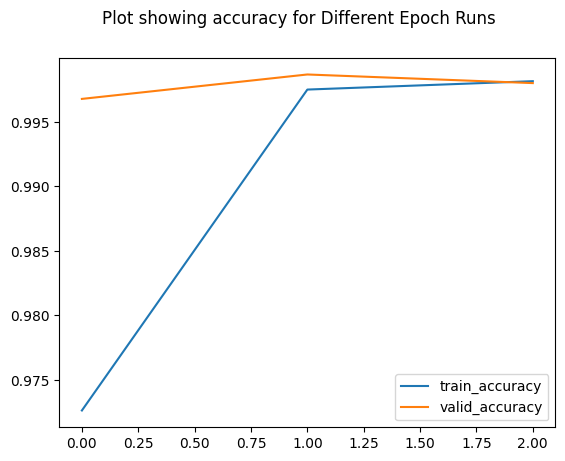

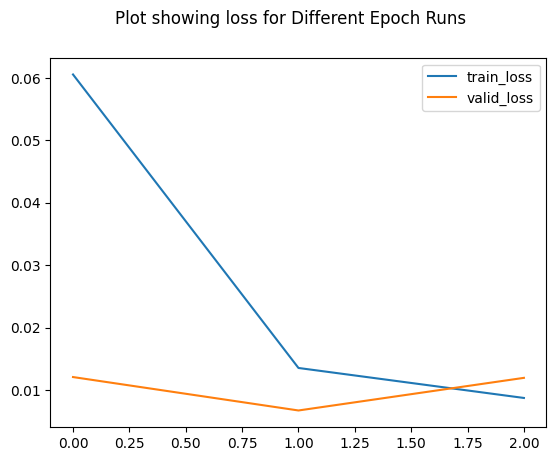

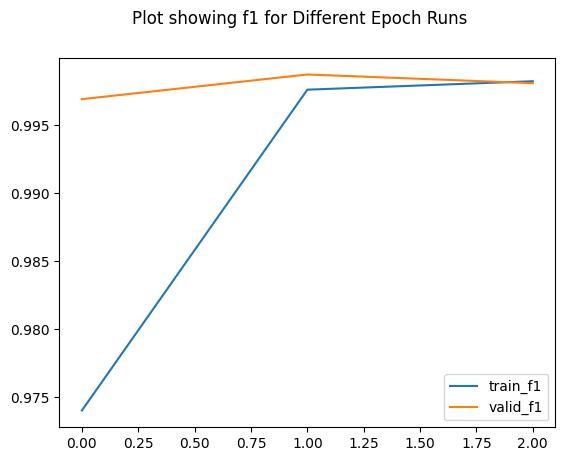

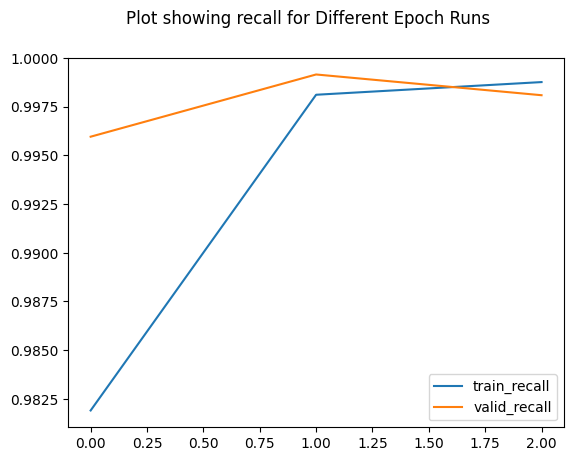

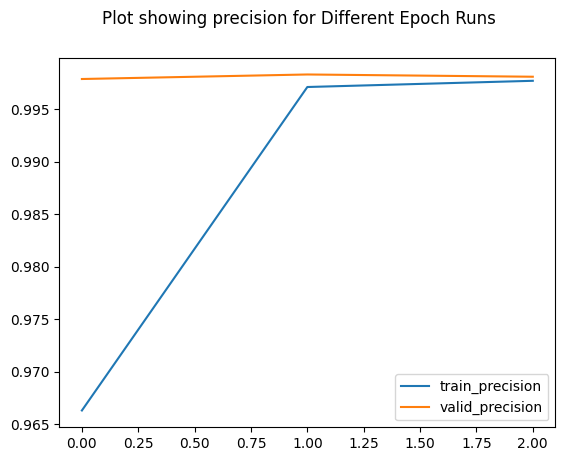

In [131]:
train_obj.plot_metrics()

In [132]:
df_test, avg_test_loss, test_accuracy = train_obj.get_test_accuracy()

Test Loss: 0.004442478577167683, Test Accuracy: 0.9994432071269488


In [133]:
avg_test_loss, test_accuracy

(0.004442478577167683, 0.9994432071269488)

In [134]:
df_test

,orig_label,pred_label
0,0.0,0.0
1,1.0,1.0
2,0.0,0.0
3,0.0,0.0
4,1.0,1.0
...,...,...
3,0.0,0.0
4,1.0,1.0
5,0.0,0.0
6,0.0,0.0


In [135]:
cm = confusion_matrix(df_test['orig_label'], df_test['pred_label'])

In [136]:
print(f'Confusion Matrix: \n {cm}  \n Recall: {cm[1,1]/(cm[1,0]+cm[1,1])}')

Confusion Matrix: 
 [[1711    2]
 [   0 1879]]  
 Recall: 1.0


In [137]:
def load_model(ckpt_path):
    embed_size = 768
    ckpt = 'roberta-base'
    num_labels = 2
    model = custom_roberta(embed_size,ckpt,num_labels)
    model.load_state_dict(torch.load(ckpt_path))
    return model

In [138]:
#model = load_model(ckpt_path)

In [139]:
#!pip install seaborn

In [140]:
# Import libraries
from pprint import pprint
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from transformers import TextClassificationPipeline
#from datasets import load_dataset
import copy
# Suppress warnings
warnings.filterwarnings("ignore")

# For reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Set up plotting
plt.style.use('ggplot')
sns.set(style="whitegrid")

# Set the device for pytorch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Libraries imported successfully!")

Libraries imported successfully!


In [141]:
# Move to GPU if available
model = model.to(device)
model.eval()  # Set to evaluation mode

print(f"Model: {ckpt}")
print(f"Device: {device}")

## Load a small test dataset (SST-2)
#test_dataset = load_dataset("glue", "sst2", split="validation[:500]")
#print(f"Test dataset loaded: {len(test_dataset)} examples")

Model: roberta-base
Device: cuda


In [142]:
# TODO: Calculate total parameters in the model
# Hint: Not sure how to inspect model layers or count parameters?
# See: https://pytorch.org/docs/stable/generated/torch.nn.Module.html
# and: https://discuss.pytorch.org/t/how-do-i-count-the-number-of-parameters-in-a-model/4325
total_params = sum(p.numel() for p in model.parameters())

# TODO: Calculate trainable parameters
# Hint: Parameters have an attribute indicating if they require gradients
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# TODO: Calculate model size in MB (assuming 32-bit float - 4 bytes per parameter)
# Hint: Convert from bytes to megabytes using the appropriate divisor
model_size_mb = total_params * 4 / (1024 * 1024)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size (MB): {model_size_mb:.2f}")

# Count attention heads
def count_attention_heads(model):
    """Count total attention heads in a transformer model."""
    total_heads = 0
    for module in model.modules():
        # TODO: Define if a module is an attention head
        # Hint: You can check modules' attributes at runtime using `module.__dict__` or `print(module)`
        is_attention_module = hasattr(module, 'num_attention_heads')
        # Check for attention modules in the model
        if is_attention_module:
            total_heads += module.num_attention_heads
            print(module, module.num_attention_heads)
            #Only attention module will have attribute num_attention_heads
    return total_heads

print(f"Total attention heads in the model: {count_attention_heads(model.basemodel)}")

Total parameters: 125,238,530
Trainable parameters: 125,238,530
Model size (MB): 477.75
RobertaSdpaSelfAttention(
  (query): Linear(in_features=768, out_features=768, bias=True)
  (key): Linear(in_features=768, out_features=768, bias=True)
  (value): Linear(in_features=768, out_features=768, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
) 12
RobertaSdpaSelfAttention(
  (query): Linear(in_features=768, out_features=768, bias=True)
  (key): Linear(in_features=768, out_features=768, bias=True)
  (value): Linear(in_features=768, out_features=768, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
) 12
RobertaSdpaSelfAttention(
  (query): Linear(in_features=768, out_features=768, bias=True)
  (key): Linear(in_features=768, out_features=768, bias=True)
  (value): Linear(in_features=768, out_features=768, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
) 12
RobertaSdpaSelfAttention(
  (query): Linear(in_features=768, out_features=768, bias=True)
  (key): Linear(in_features=76

In [143]:
def evaluate_model(model, device):
    """Evaluate model accuracy and latency on a dataset."""
    # Move model to evaluation mode
    model.eval()
    t1 = time.time()
    train_obj.device = device
    train_obj.model = model
    df_test, avg_test_loss, accuracy = train_obj.get_test_accuracy()
    t2 = time.time()
    avg_latency = 1000 * (t2-t1)/len(test_dl)  # Latency per example
    
    # TODO: Calculate model size in MB
    # Hint: You need to calculate the model size, but then you can reuse the same logic as in Step 3 to move to MB
    model_size = sum(p.nelement() * p.element_size() for p in model.parameters()) / (1024 * 1024)
    
    return {
        "accuracy": accuracy,
        "avg_latency_ms": avg_latency,
        "model_size_mb": model_size
    }

def print_evaluate(model, device):
    # Evaluate original model
    print("Evaluating model...")
    original_metrics = evaluate_model(model, device)

    print(f"Model metrics:")
    print(f"- Accuracy: {original_metrics['accuracy']:.4f}")
    print(f"- Avg Latency: {original_metrics['avg_latency_ms']:.2f} ms")
    print(f"- Model Size: {original_metrics['model_size_mb']:.2f} MB")
    return original_metrics

In [144]:
# Function to analyze attention head importance
def analyze_head_importance(model, inp_ids, att_mask, device):
    """Analyze the importance of each attention head."""
    head_importance = {}
    model.eval()
    
    # Get attention modules
    attention_modules = []
    for name, module in model.basemodel.named_modules():
        # TODO: Define if a module is an attention head
        # Hint: You can reuse the same logic as in Step 3.
        is_attention_module = hasattr(module, 'num_attention_heads')
        if is_attention_module:
            attention_modules.append((name, module))
    
    # Sample some data
    #inputs = tokenizer(dataset["sentence"][:num_samples], 
    #                   padding=True, 
    #                   truncation=True, 
    #                   return_tensors="pt").to(device)
    
    # Get baseline outputs
    with torch.no_grad():
        baseline_outputs = model(inp_ids, att_mask)
        baseline_probs = torch.softmax(baseline_outputs, dim=1)
    
    # For each attention module and head
    for module_name, module in attention_modules:
        head_importance[module_name] = []
        
        # For each head in this module
        for head_idx in range(module.num_attention_heads):
            # Mask a specific attention head and measure its impact
            def mask_head(module, inp_ids, att_mask, head_idx=head_idx):
                # Store the original attention output
                original_func = module.forward
                
                # Define a new forward function that masks a specific head
                def masked_forward(*args, **kwargs):
                    outputs = original_func(*args, **kwargs)
                    ##print(outputs)
                    # Mask the attention scores for this head
                    if isinstance(outputs, tuple):
                        attn_output = outputs[0]
                        #print(attn_output)
                        head_size = attn_output.size(-1) // module.num_attention_heads
                        # TODO: Create indices to zero out for this specific head
                        # Hint: Each head occupies a contiguous block of size `head_size` in the last dimension.
                        # Calculate the start and end index for the block belonging to `head_idx`, and pass it to torch.arange() with the right device
                        indices = torch.arange(head_size * head_idx, head_size * (head_idx + 1), 
                                              device=attn_output.device)
                        attn_output[:, :, indices] = 0
                        return outputs
                    return outputs
                
                # Replace the forward method
                module.forward = masked_forward
                
                # Run the model
                with torch.no_grad():
                    masked_outputs = model(inp_ids, att_mask)
                    masked_probs = torch.softmax(masked_outputs, dim=1)
                
                # Restore the original forward method
                module.forward = original_func
                #print("I came here")
                
                return masked_probs
            
            # Run the model with this head masked
            masked_probs = mask_head(module, inp_ids, att_mask)
            
            # TODO: Calculate head importance as the difference in output when the head is masked
            # Hint: Consider how to measure the difference between two probability distributions
            prob_diff = torch.abs(masked_probs - baseline_probs).mean().item()
            head_importance[module_name].append(prob_diff)
    
    print(f"Analysis completed.")
    return head_importance

In [145]:
def visualize_heads_prune_list(head_importance, per_prune=0.84):
    # Visualize head importance
    plt.figure(figsize=(12, 6))
    for module_name, importances in head_importance.items():
        module_name = module_name.split('.')[-1]  # Shorten the name
        plt.bar(
            [f"{module_name}-{i}" for i in range(len(importances))], importances
            )
    plt.xticks(rotation=90)
    plt.title("Attention Head Importance")
    plt.xlabel("Attention Heads")
    plt.ylabel("Importance Score (higher = more important)")
    plt.tight_layout()
    plt.show()

    # TODO: Determine how many heads to prune based on a pruning rate
    # Hint: Consider what percentage of heads you want to remove
    pruning_rate = per_prune #0.3  # 30% of heads will be pruned

    # TODO: Calculate the number of heads to prune based on the pruning rate
    # Hint: Count the total number of heads and apply the rate
    n_heads_to_prune = int(sum(len(imp) for imp in head_importance.values()) * pruning_rate)
    print(f'prune baby prune...{n_heads_to_prune}, {len(head_importance)}')

    # Flatten and sort all heads by importance
    all_heads = []
    for module_name, importances in head_importance.items():
        for i, imp in enumerate(importances):
            all_heads.append((module_name, i, imp))

    # TODO: Sort heads by importance to identify which to prune first
    # Hint: Each item is a tuple of (module_name, head_idx, importance). Also, should you prune in ascending or descending order?
    # Finally, feel free to sort in place instead!
    all_heads.sort(key=lambda item: item[2])

    # Get the least important heads
    heads_to_prune = all_heads[:n_heads_to_prune]
    print(f"Pruning {len(heads_to_prune)} heads with lowest importance scores")

    # Print the heads to be pruned
    for module_name, head_idx, imp in heads_to_prune:
        print(f"Pruning {module_name} head {head_idx} (importance: {imp:.6f})")
    return heads_to_prune

In [146]:
def prune_heads_in_model(model, heads_to_prune):
    """Prune attention heads in the model using Hugging Face's built-in method."""
    # Format the heads to prune into a dictionary that matches HuggingFace's format
    # {layer_num: [list of heads to prune in this layer]}
    pruning_dict = {}
    
    # Create a dictionary of heads to prune by layer index
    for module_name, head_idx, _ in heads_to_prune:
        # Extract layer index from module name (e.g., 'transformer.layer.0.attention')
        layer_parts = module_name.split('.')
        for i, part in enumerate(layer_parts):
            if part == 'layer' and i+1 < len(layer_parts) and layer_parts[i+1].isdigit():
                layer_idx = int(layer_parts[i+1])
                
                # TODO: Update the pruning dictionary for this layer for pruning
                # Hint: The expected output is a list. What would an empty list represent here?
                if layer_idx not in pruning_dict:
                    pruning_dict[layer_idx] = []
                pruning_dict[layer_idx].append(head_idx)
                break
    
    # Print the pruning plan
    print("Pruning plan:")
    for layer_idx, heads in pruning_dict.items():
        print(f"Layer {layer_idx}: Pruning heads {heads}")
    
    # Clone the model to avoid modifying the original
    #pruned_model = type(model)(model.basemodel.config)
    #pruned_model.load_state_dict(model.state_dict())
    #pruned_model = pruned_model.to(device)
    pruned_model = copy.deepcopy(model)
    pruned_model = pruned_model.to(device)
    # Perform pruning layer by layer
    for layer_idx, heads in pruning_dict.items():
        # Find the attention module for this layer
        attention_module = None
        for name, module in pruned_model.basemodel.named_modules():
            if f'layer.{layer_idx}.attention' in name and hasattr(module, 'prune_heads'):
                attention_module = module
                break
        
        if attention_module is not None:
            # TODO: Prune the defined attention heads for the module
            # Hint: Hugging Face provides a built-in functionality that updated attention_module in place!
            # See: https://huggingface.co/docs/transformers/main/main_classes/model
            # Add your one-line code here
            attention_module.prune_heads(heads)
        else:
            print(f"Warning: Could not find attention module for layer {layer_idx}")
    
    return pruned_model

In [147]:
def compare_prune_orig(pruned_metrics, original_metrics):
    print(f"Pruned model metrics:")
    print(f"- Accuracy: {pruned_metrics['accuracy']:.4f}")
    print(f"- Avg Latency: {pruned_metrics['avg_latency_ms']:.2f} ms")
    print(f"- Model Size: {pruned_metrics['model_size_mb']:.2f} MB")

    # Compare before and after pruning
    print("\nComparison:")
    print(f"Accuracy change: {(pruned_metrics['accuracy'] - original_metrics['accuracy']) * 100:.2f}%")
    print(f"Latency improvement: {(1 - pruned_metrics['avg_latency_ms'] / original_metrics['avg_latency_ms']) * 100:.2f}%")
    print(f"Size reduction: {(1 - pruned_metrics['model_size_mb'] / original_metrics['model_size_mb']) * 100:.2f}%")

In [201]:
inp = next(iter(test_dl))
inp_ids = inp[0].to(device)
att_mask = inp[2].to(device)
inp_ids.shape, att_mask.shape
model.eval()
print(model(inp_ids, att_mask).shape)
# Analyze head importance
print("Analyzing attention head importance...")
head_importance = analyze_head_importance(model, inp_ids, att_mask, device)
pprint(head_importance)

torch.Size([32, 2])
Analyzing attention head importance...
Analysis completed.
{'encoder.layer.0.attention.self': [0.00013763718015979975,
                                    0.00014446275599766523,
                                    0.0002442513359710574,
                                    0.00012401395360939205,
                                    6.108421075623482e-05,
                                    0.00015240231005009264,
                                    0.00014909282617736608,
                                    0.0002718017785809934,
                                    5.057215457782149e-05,
                                    0.00010336384002584964,
                                    0.00031358428532257676,
                                    0.00021236787142697722],
 'encoder.layer.1.attention.self': [1.77805468410952e-05,
                                    7.218522659968585e-05,
                                    3.383801595191471e-05,
                            

In [203]:
def chk_rem_prune_heads(heads_to_prune, num_heads):
    '''
    This function makes sure that at least one head remains in each transformer layer
    This is to make sure 8 bit torch quantization works smoothly
    '''
    
    layer_dict = {f'encoder.layer.{i}.attention.self': 0 for i in range(num_heads)}
    print(layer_dict)
    heads_to_prune_copy = heads_to_prune.copy()
    for i in heads_to_prune_copy:
        layer_dict[i[0]] += 1
        if layer_dict[i[0]] > 11:
            heads_to_prune.remove(i)
            print(f'Removed {i} from heads_to prune')
    print(f'Original heads to prune {len(heads_to_prune_copy)}\nNew heads to prune list: {len(heads_to_prune)}')
    return heads_to_prune

In [204]:
len(heads_to_prune)

136

In [205]:
def run_heads_prune_exp(head_importance, model, device, target_accuracy, per_prune, quantize=False):
    #per_prune = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    original_metrics = print_evaluate(model, device)
    print(original_metrics)
    acc_list = []
    quant_acc_list = []
    for p in per_prune:
        heads_to_prune = visualize_heads_prune_list(head_importance, per_prune=p)
        heads_to_prune = chk_rem_prune_heads(heads_to_prune, num_heads=12)
        pruned_model = prune_heads_in_model(model, heads_to_prune)
        print("Evaluating pruned model...")
        pruned_metrics = print_evaluate(pruned_model, device)
        acc_list.append((p,pruned_metrics['accuracy']))
        compare_prune_orig(pruned_metrics, original_metrics)
        if quantize:
            pruned_model = pruned_model.to('cpu')
            quantized_dynamic_model = torch.quantization.quantize_dynamic(
                pruned_model,
                {nn.Linear},
                dtype=torch.qint8
                )
            quant_metrics = print_evaluate(quantized_dynamic_model, device='cpu')
            quant_acc_list.append((p,quant_metrics['accuracy']))
            print("Comparing quantized model metrics now....")
            compare_prune_orig(quant_metrics, original_metrics)
            accuracy = quant_metrics['accuracy']
        else:
            quant_acc_list = None
            quant_metrics = None
            quantized_dynamic_model = None
            accuracy = pruned_metrics['accuracy']
        if accuracy <= target_accuracy:
            return original_metrics, acc_list, quant_acc_list, pruned_metrics, quant_metrics, pruned_model, quantized_dynamic_model
    
    return original_metrics, acc_list, quant_acc_list, pruned_metrics, quant_metrics, pruned_model, quantized_dynamic_model

In [206]:
per_prune = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
target_accuracy = 0.96
device = 'cuda'

Evaluating model...
Test Loss: 0.004442478577167683, Test Accuracy: 0.9994432071269488
Model metrics:
- Accuracy: 0.9994
- Avg Latency: 59.00 ms
- Model Size: 477.75 MB
{'accuracy': 0.9994432071269488, 'avg_latency_ms': 58.99850246125618, 'model_size_mb': 477.74707794189453}


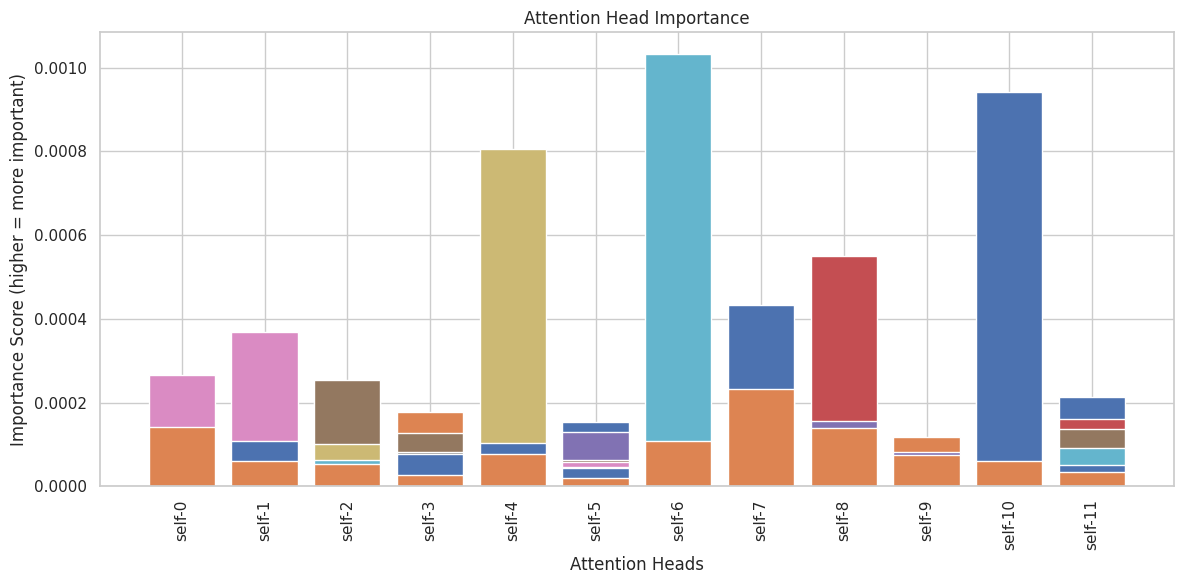

prune baby prune...14, 12
Pruning 14 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.at

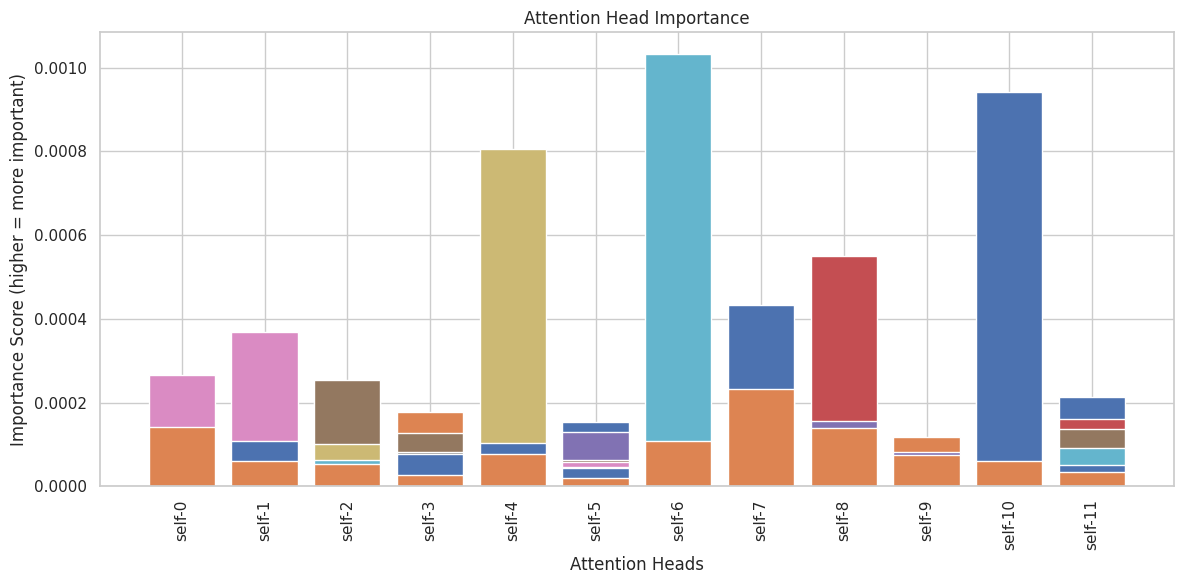

prune baby prune...28, 12
Pruning 28 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.at

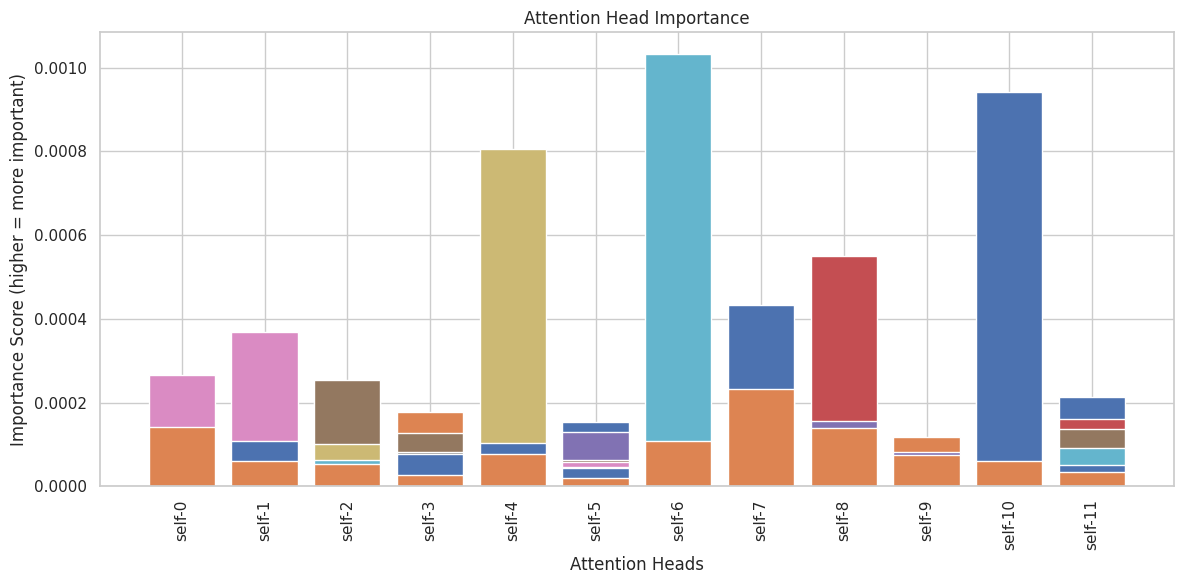

prune baby prune...43, 12
Pruning 43 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.at

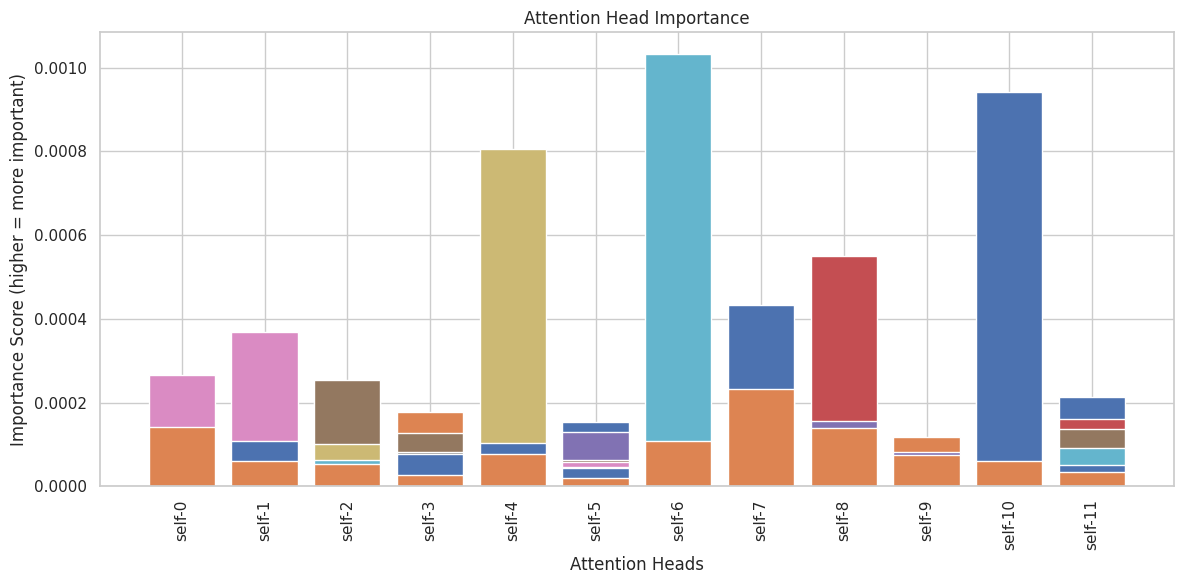

prune baby prune...57, 12
Pruning 57 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.at

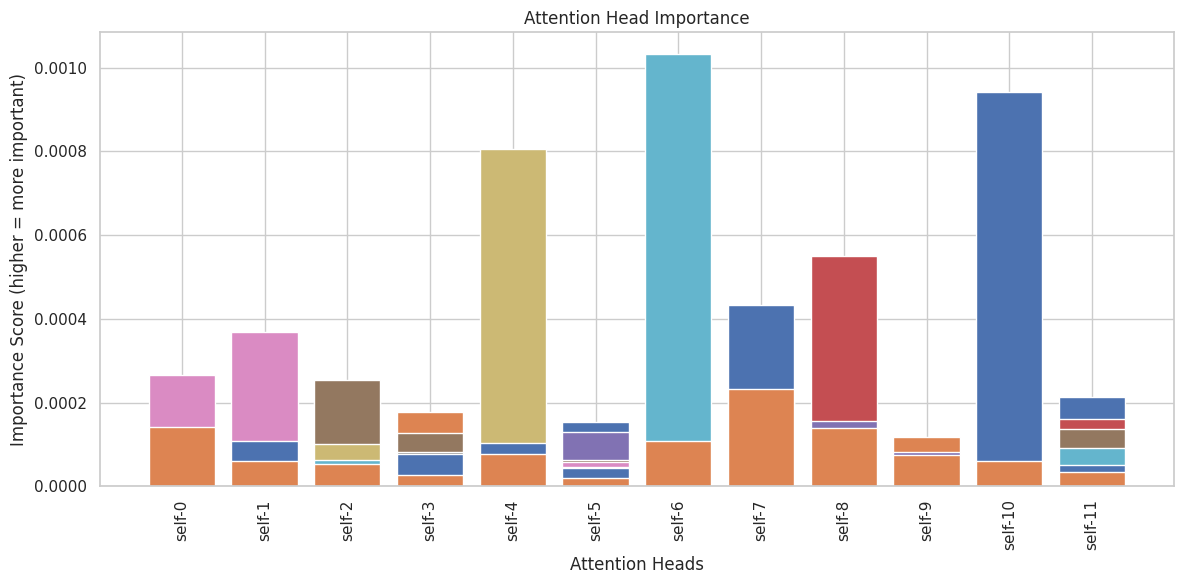

prune baby prune...72, 12
Pruning 72 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.at

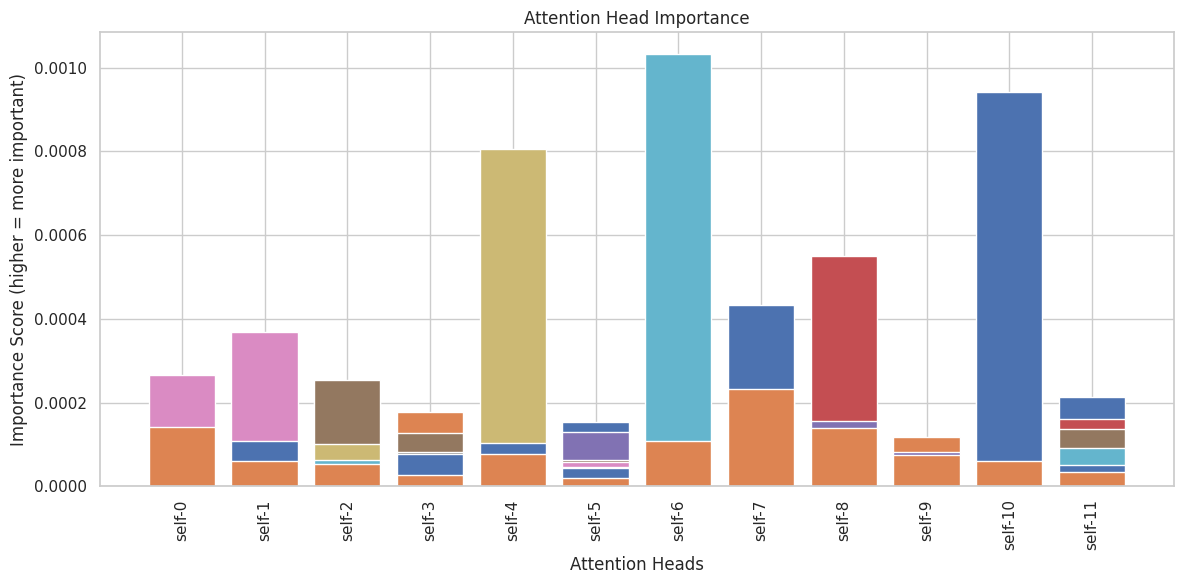

prune baby prune...86, 12
Pruning 86 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.at

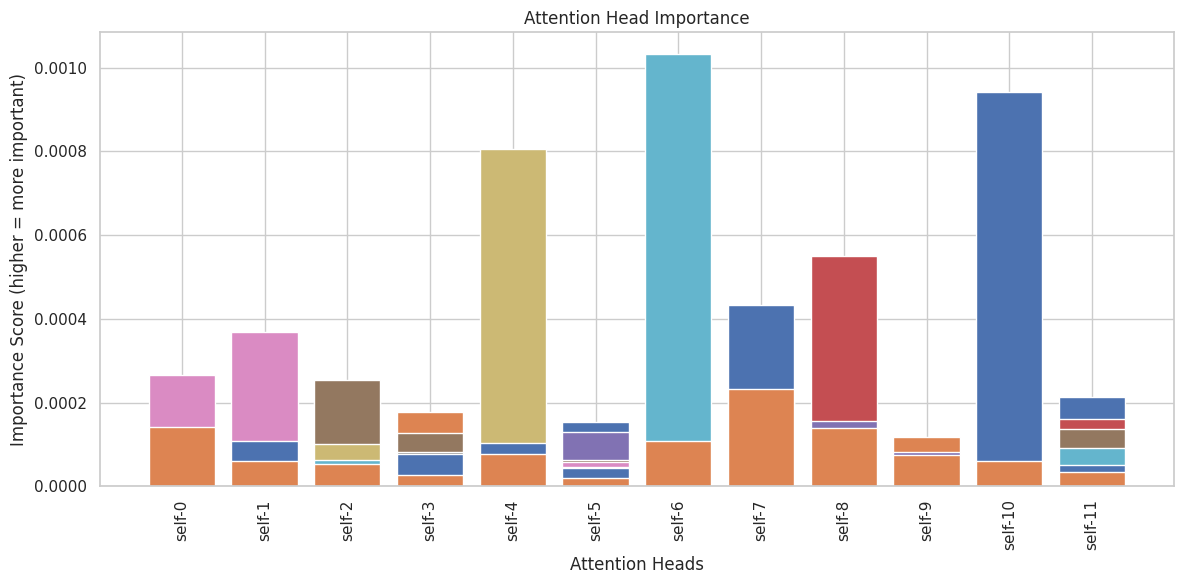

prune baby prune...100, 12
Pruning 100 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.

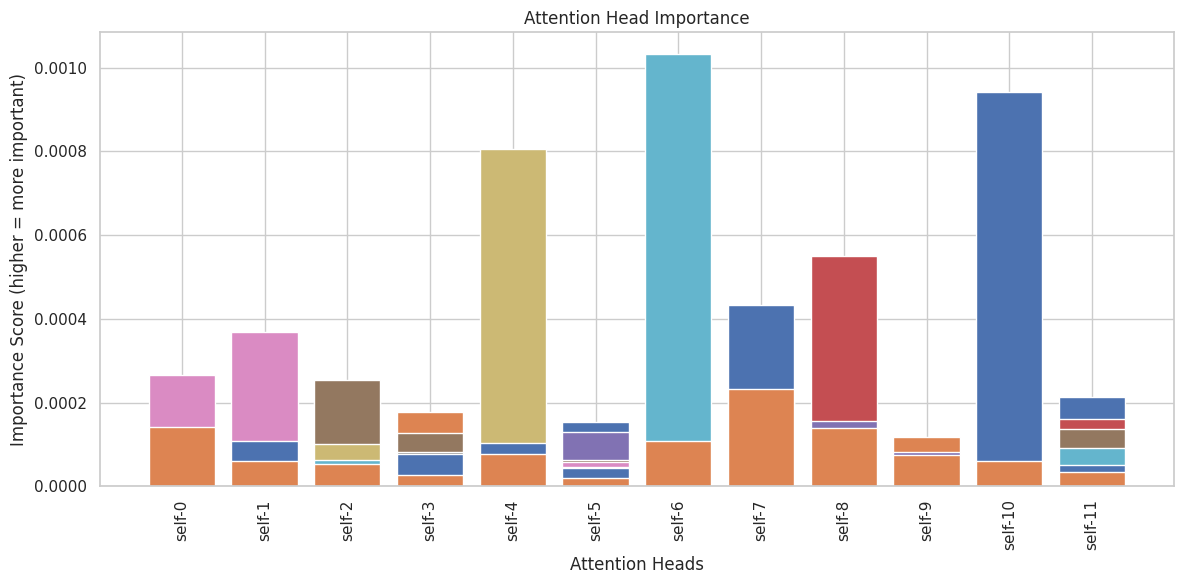

prune baby prune...115, 12
Pruning 115 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.

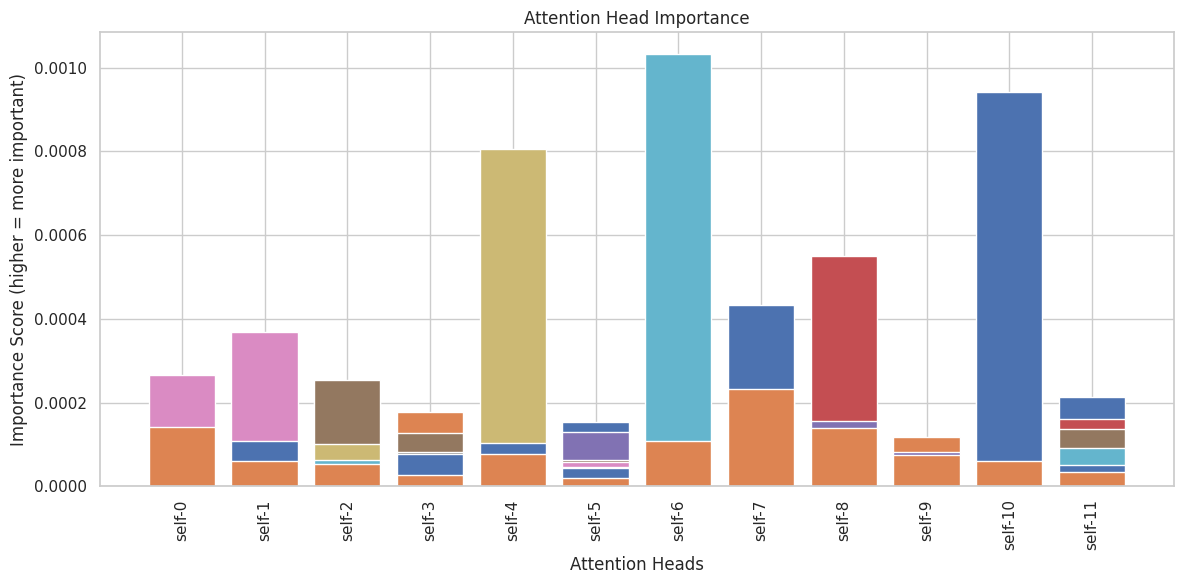

prune baby prune...129, 12
Pruning 129 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.

In [207]:
original_metrics, acc_list, quant_acc_list, pruned_metrics, quant_metrics, pruned_model, quantized_dynamic_model = run_heads_prune_exp(head_importance, model, device, target_accuracy, per_prune, quantize=False)

In [208]:
original_metrics, acc_list, pruned_metrics

({'accuracy': 0.9994432071269488,
  'avg_latency_ms': 58.99850246125618,
  'model_size_mb': 477.74707794189453},
 [(0.1, 0.9991648106904232),
  (0.2, 0.9988864142538976),
  (0.3, 0.998608017817372),
  (0.4, 0.9983296213808464),
  (0.5, 0.9974944320712695),
  (0.6, 0.9741091314031181),
  (0.7, 0.9699331848552338),
  (0.8, 0.9688195991091314),
  (0.9, 0.8697104677060133)],
 {'accuracy': 0.8697104677060133,
  'avg_latency_ms': 46.43373995755626,
  'model_size_mb': 383.15479278564453})

Evaluating model...
Test Loss: 0.004442478577167683, Test Accuracy: 0.9994432071269488
Model metrics:
- Accuracy: 0.9994
- Avg Latency: 59.36 ms
- Model Size: 477.75 MB
{'accuracy': 0.9994432071269488, 'avg_latency_ms': 59.3560796923342, 'model_size_mb': 477.74707794189453}


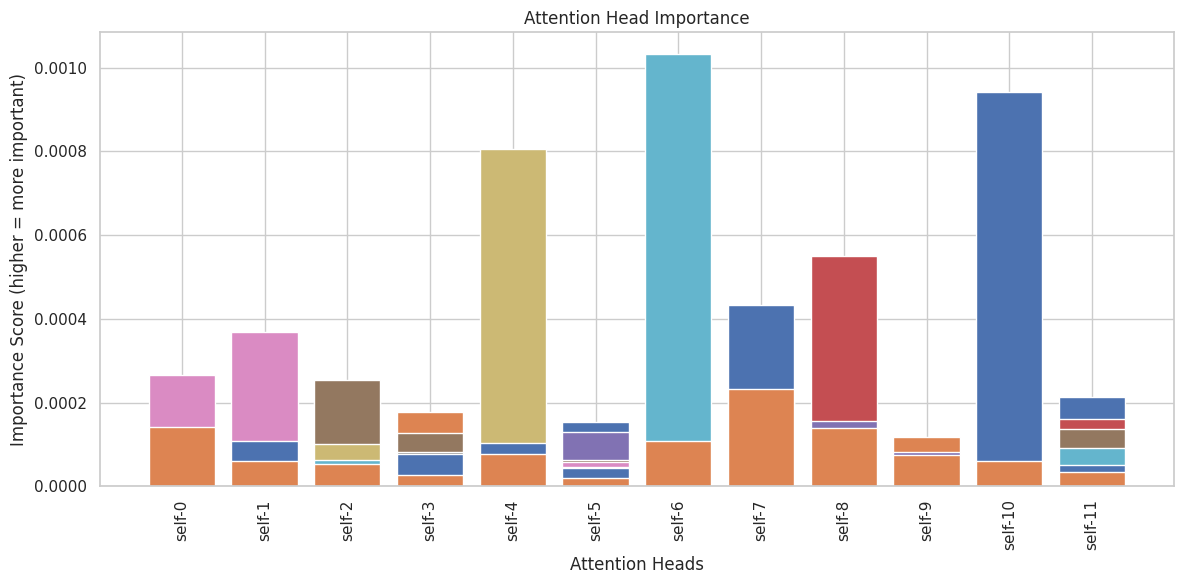

prune baby prune...14, 12
Pruning 14 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.at

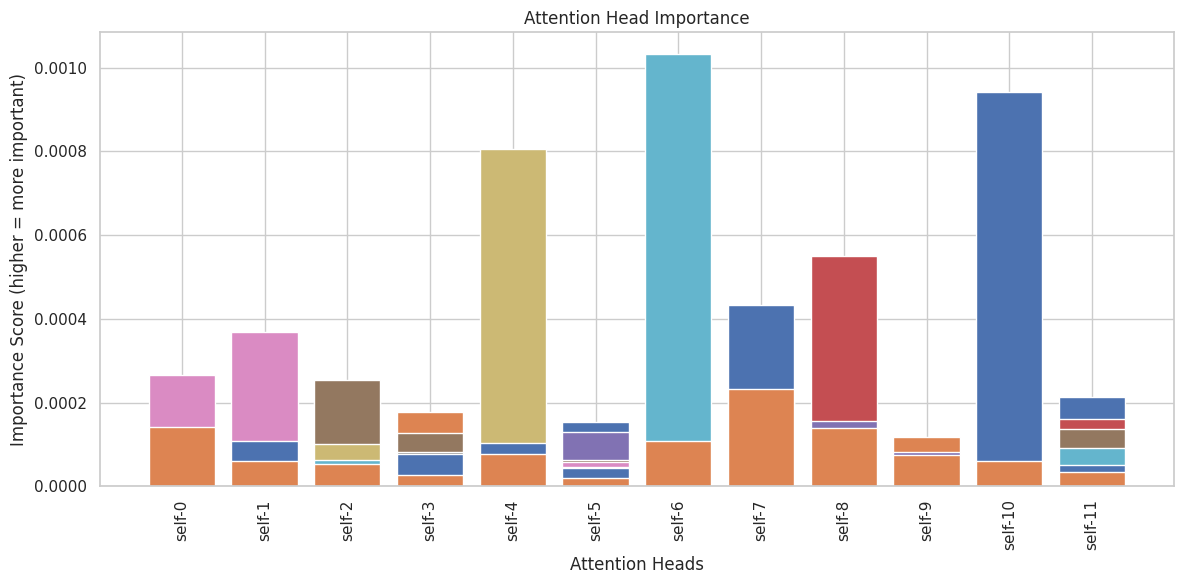

prune baby prune...28, 12
Pruning 28 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.at

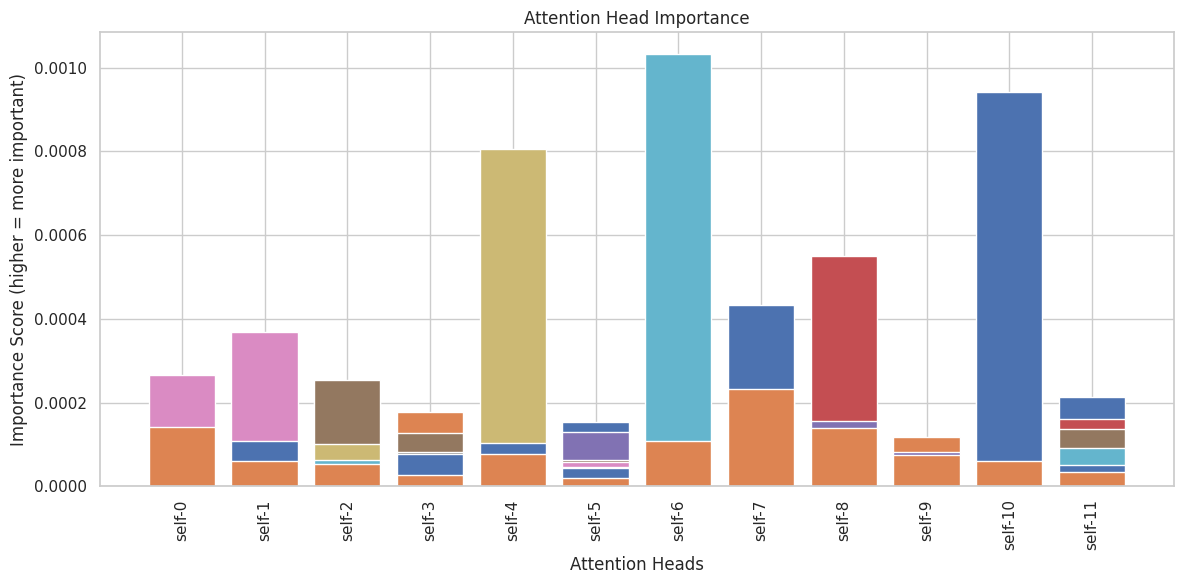

prune baby prune...43, 12
Pruning 43 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.at

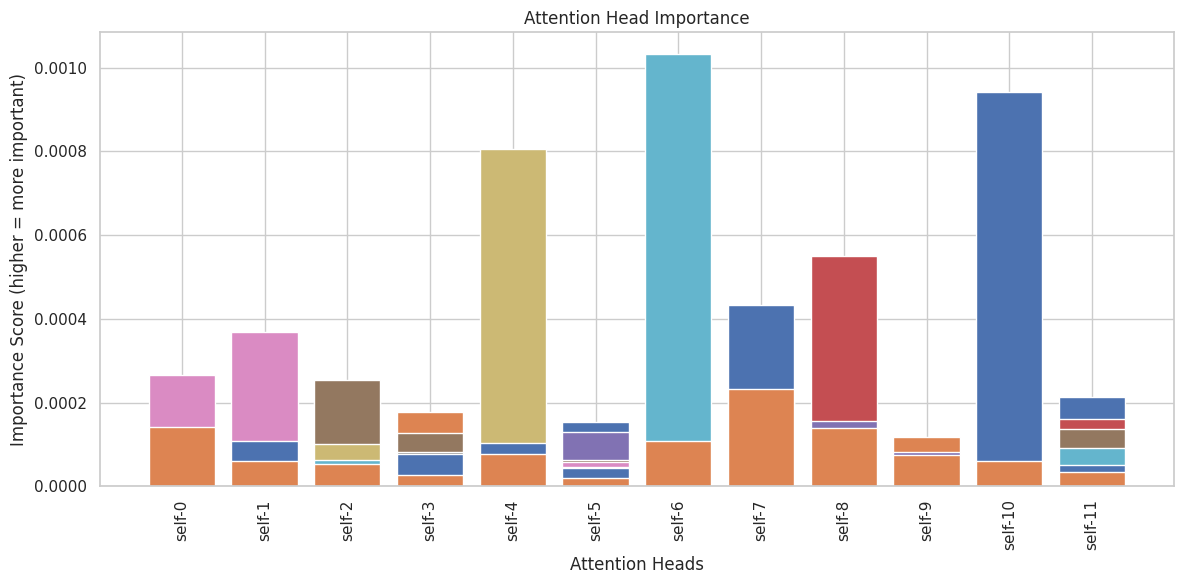

prune baby prune...57, 12
Pruning 57 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.at

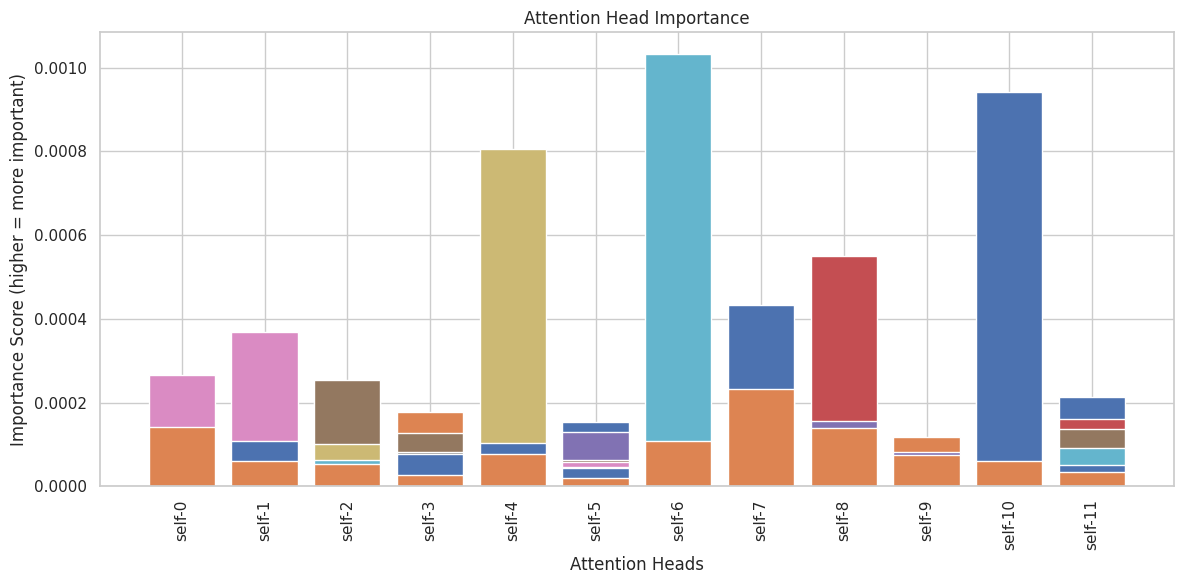

prune baby prune...72, 12
Pruning 72 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.at

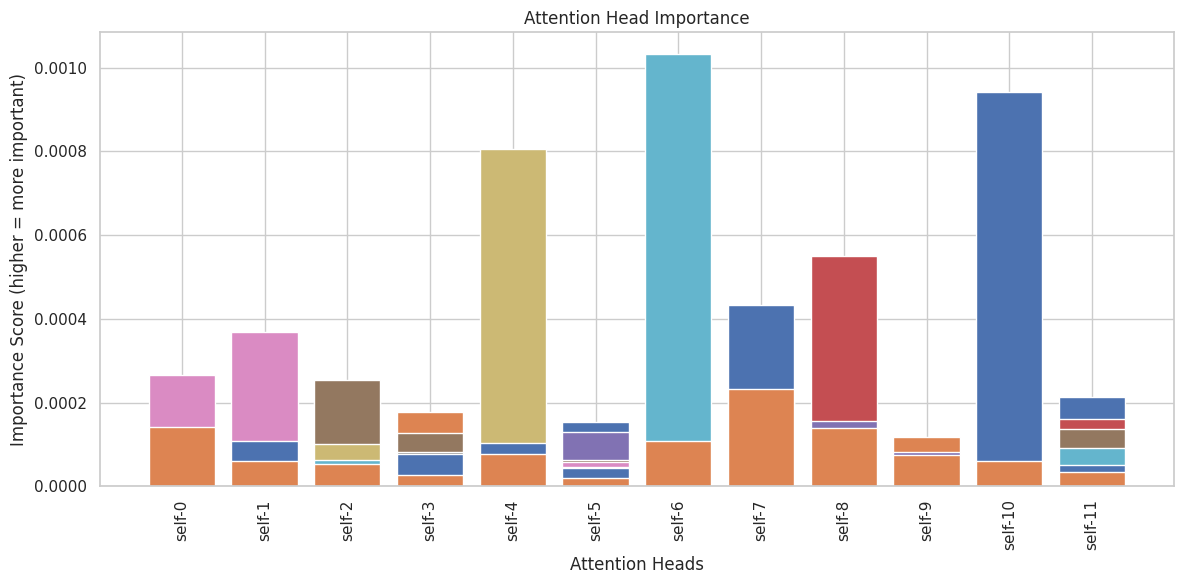

prune baby prune...86, 12
Pruning 86 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.at

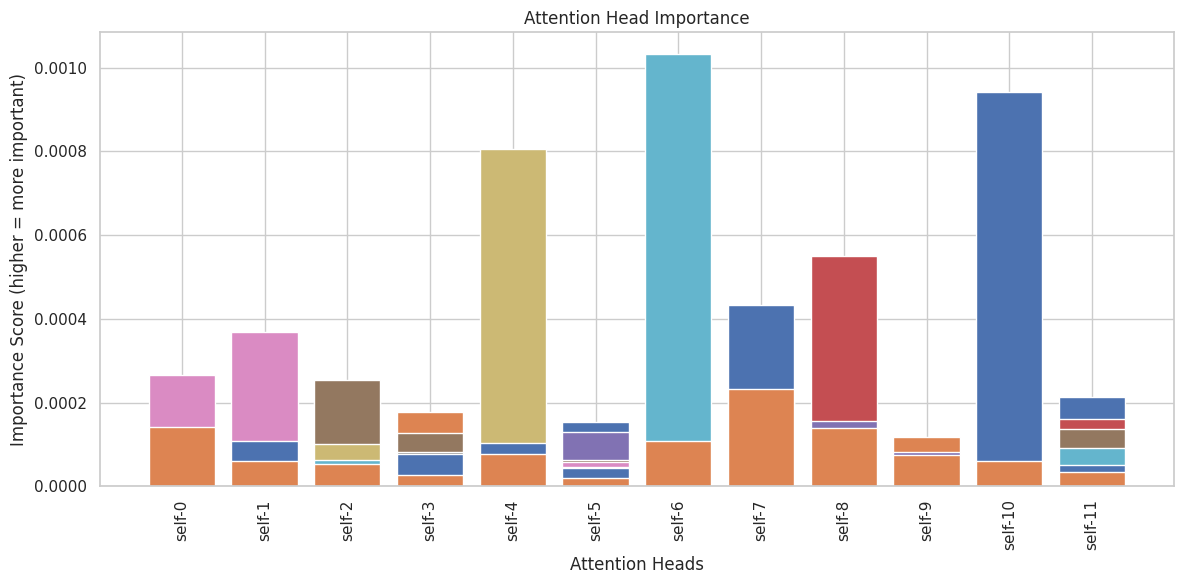

prune baby prune...100, 12
Pruning 100 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.

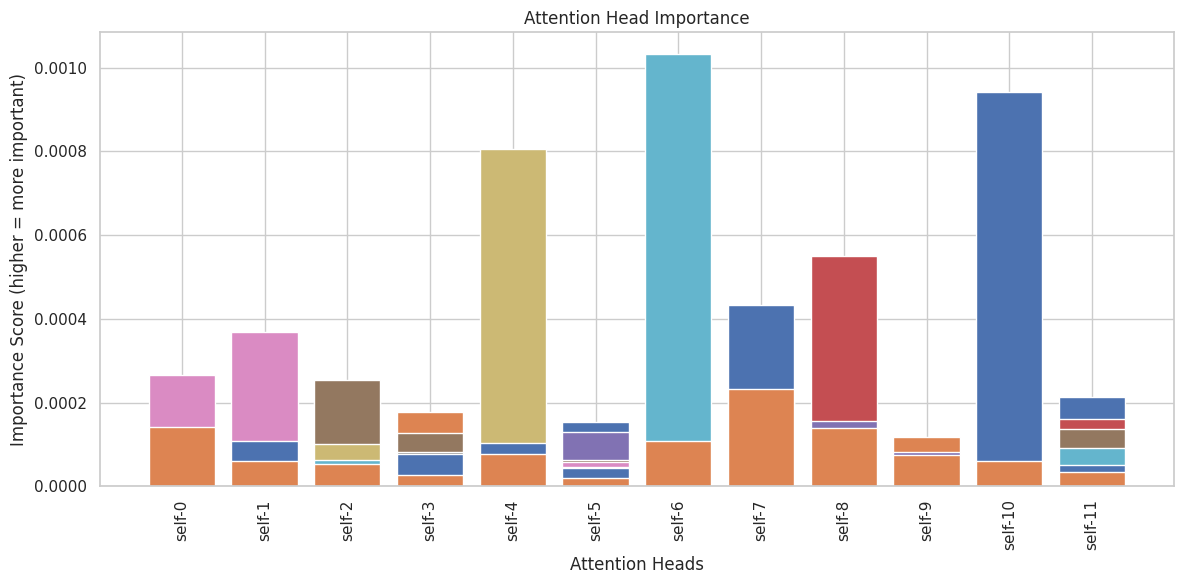

prune baby prune...115, 12
Pruning 115 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.

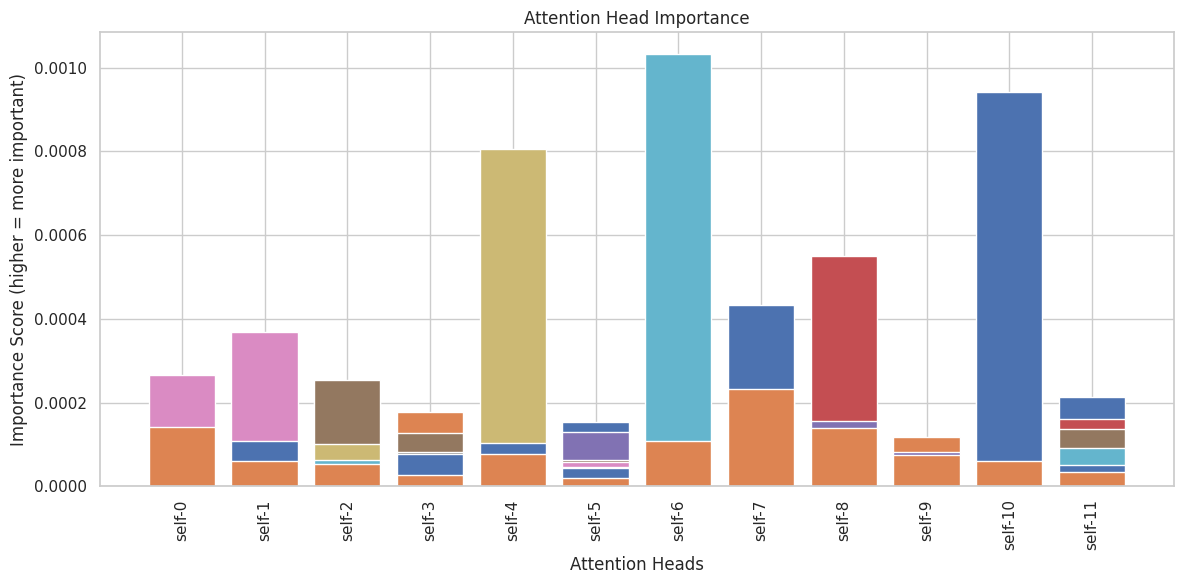

prune baby prune...116, 12
Pruning 116 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.

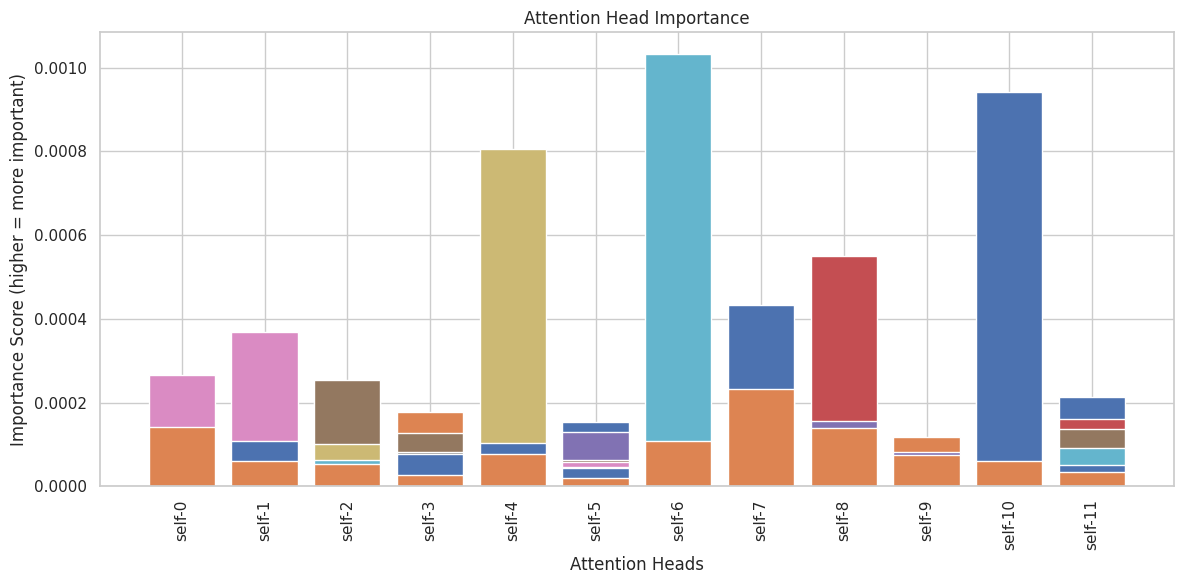

prune baby prune...118, 12
Pruning 118 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.

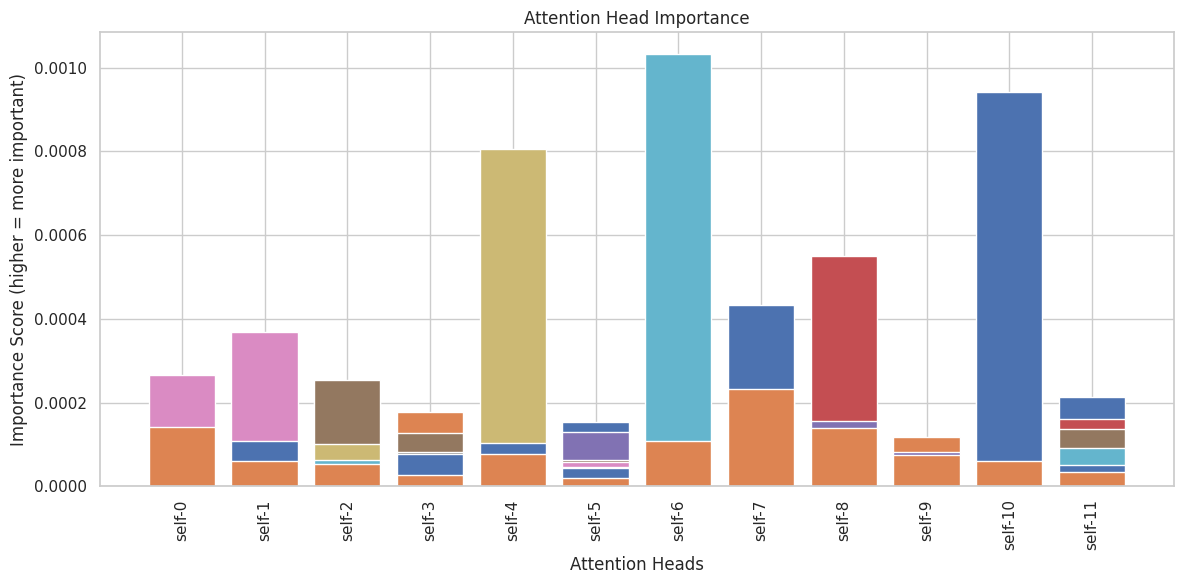

prune baby prune...119, 12
Pruning 119 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.

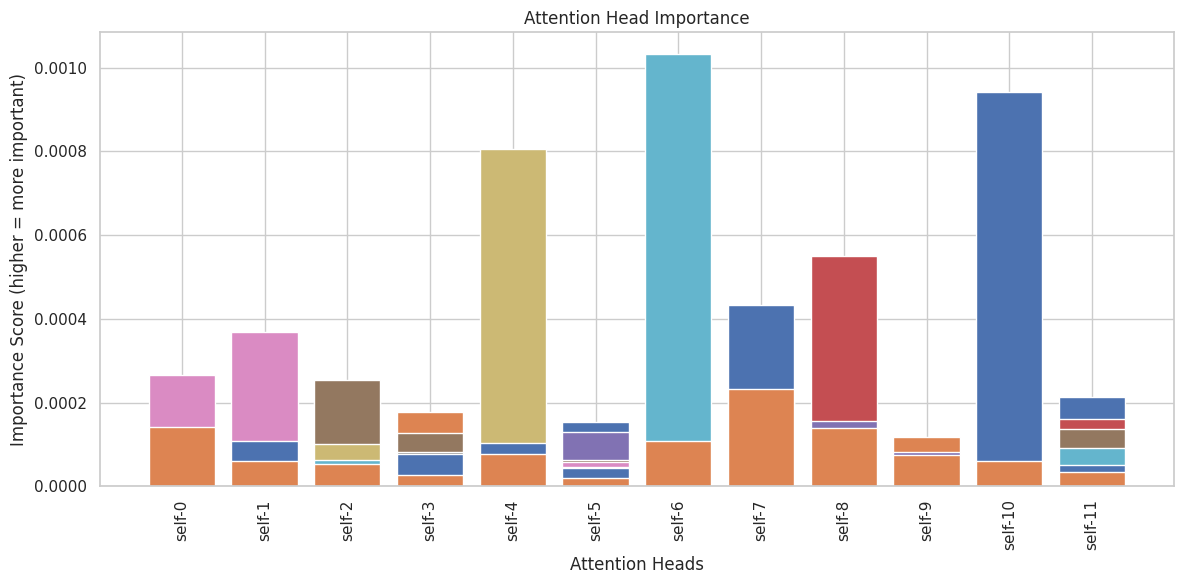

prune baby prune...120, 12
Pruning 120 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.

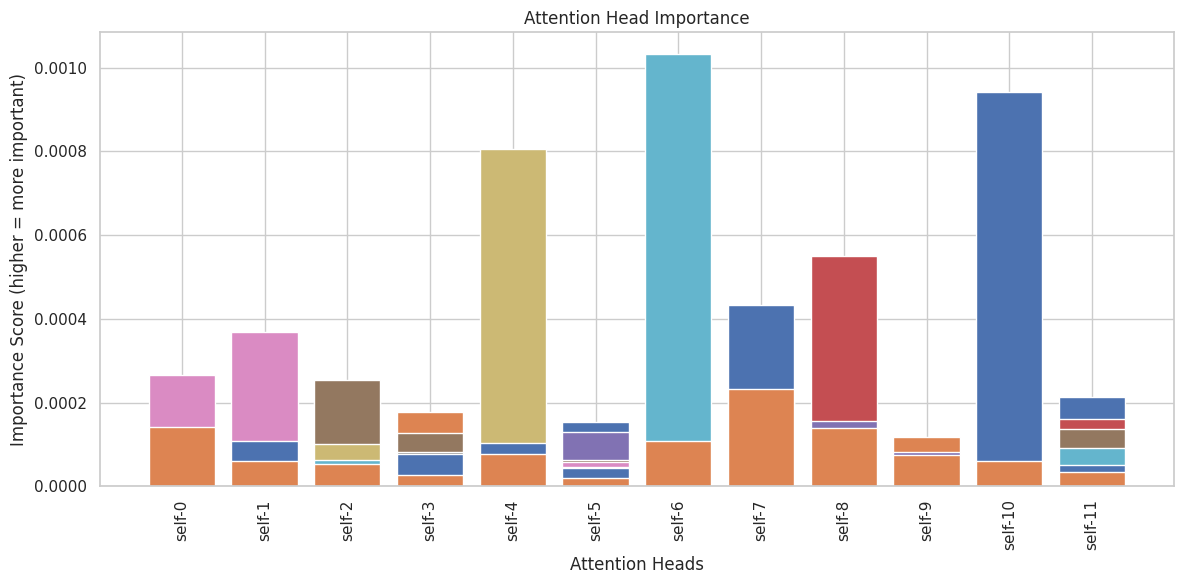

prune baby prune...122, 12
Pruning 122 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.

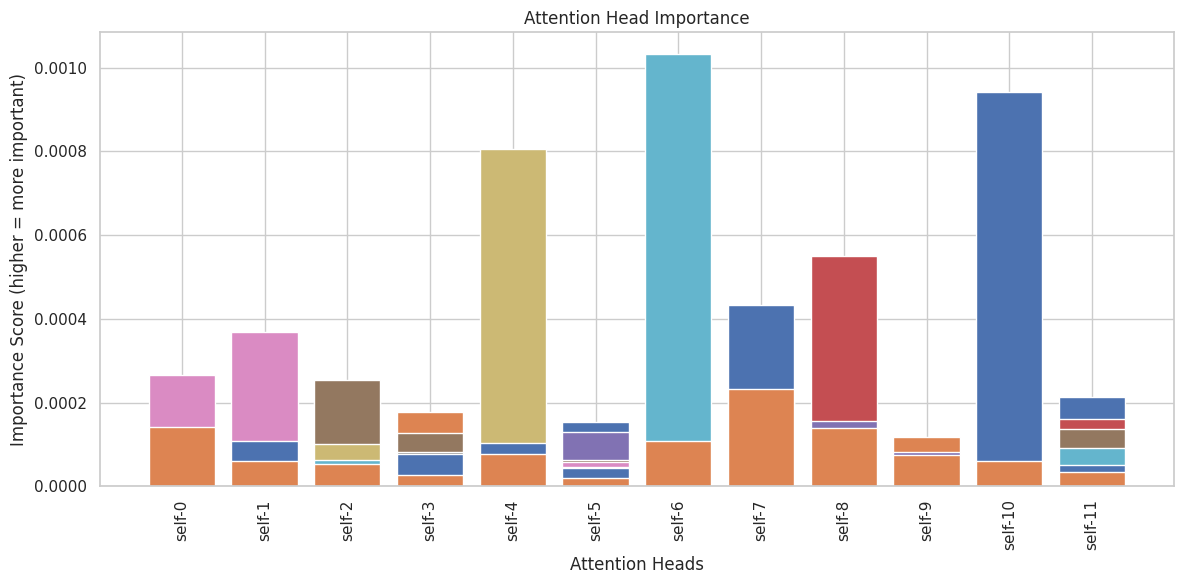

prune baby prune...123, 12
Pruning 123 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.

({'accuracy': 0.9994432071269488,
  'avg_latency_ms': 59.3560796923342,
  'model_size_mb': 477.74707794189453},
 [(0.1, 0.9991648106904232),
  (0.2, 0.9988864142538976),
  (0.3, 0.998608017817372),
  (0.4, 0.9983296213808464),
  (0.5, 0.9974944320712695),
  (0.6, 0.9741091314031181),
  (0.7, 0.9699331848552338),
  (0.8, 0.9688195991091314),
  (0.81, 0.969097995545657),
  (0.82, 0.9685412026726058),
  (0.83, 0.9685412026726058),
  (0.84, 0.9688195991091314),
  (0.85, 0.9671492204899778),
  (0.86, 0.9562917594654788)],
 {'accuracy': 0.9562917594654788,
  'avg_latency_ms': 47.1356400346334,
  'model_size_mb': 386.90845489501953})

In [209]:
per_prune = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88, 0.89]
target_accuracy = 0.96
device = 'cuda'
original_metrics, acc_list, quant_acc_list, pruned_metrics, quant_metrics, pruned_model, quantized_dynamic_model = run_heads_prune_exp(head_importance, model, device, target_accuracy, per_prune, quantize=False)
original_metrics, acc_list, pruned_metrics

Evaluating model...
Test Loss: 0.004442478577167683, Test Accuracy: 0.9994432071269488
Model metrics:
- Accuracy: 0.9994
- Avg Latency: 59.92 ms
- Model Size: 477.75 MB
{'accuracy': 0.9994432071269488, 'avg_latency_ms': 59.91996706059549, 'model_size_mb': 477.74707794189453}


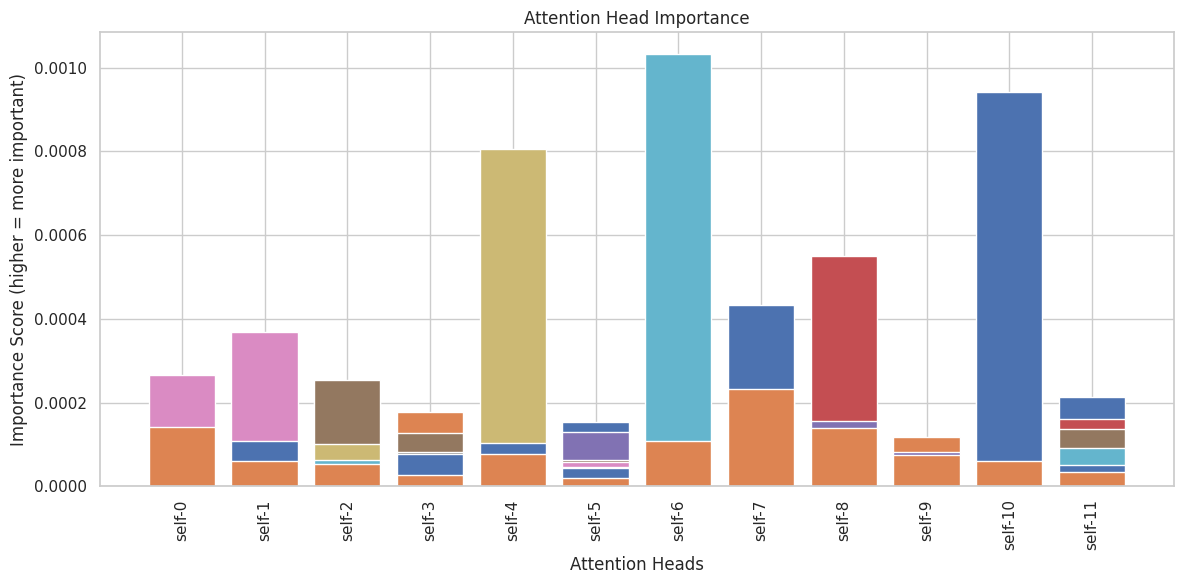

prune baby prune...14, 12
Pruning 14 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.at

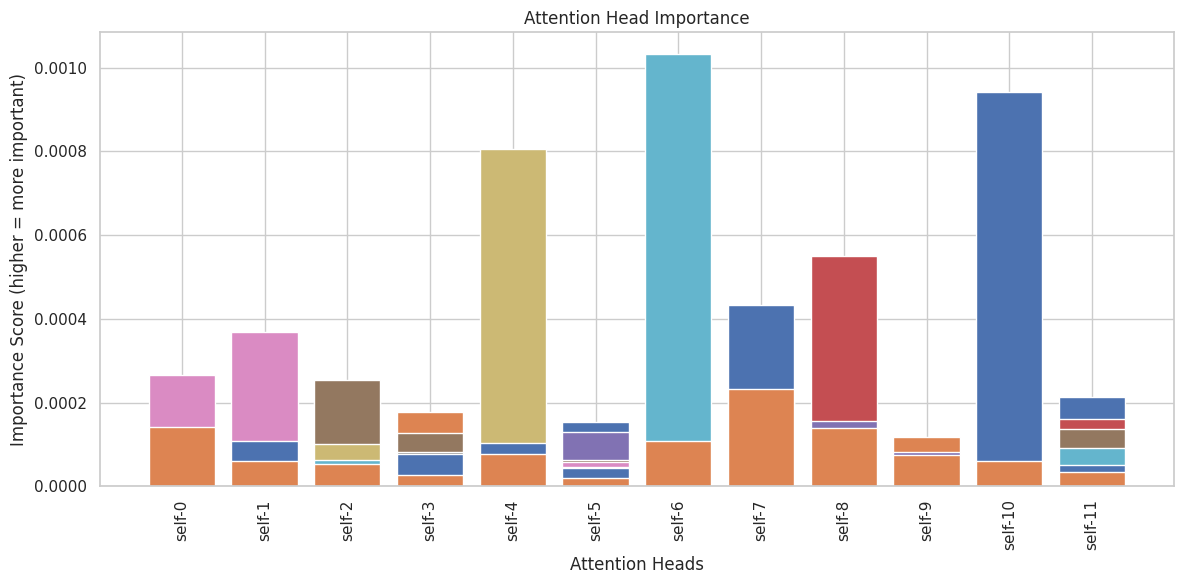

prune baby prune...28, 12
Pruning 28 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.at

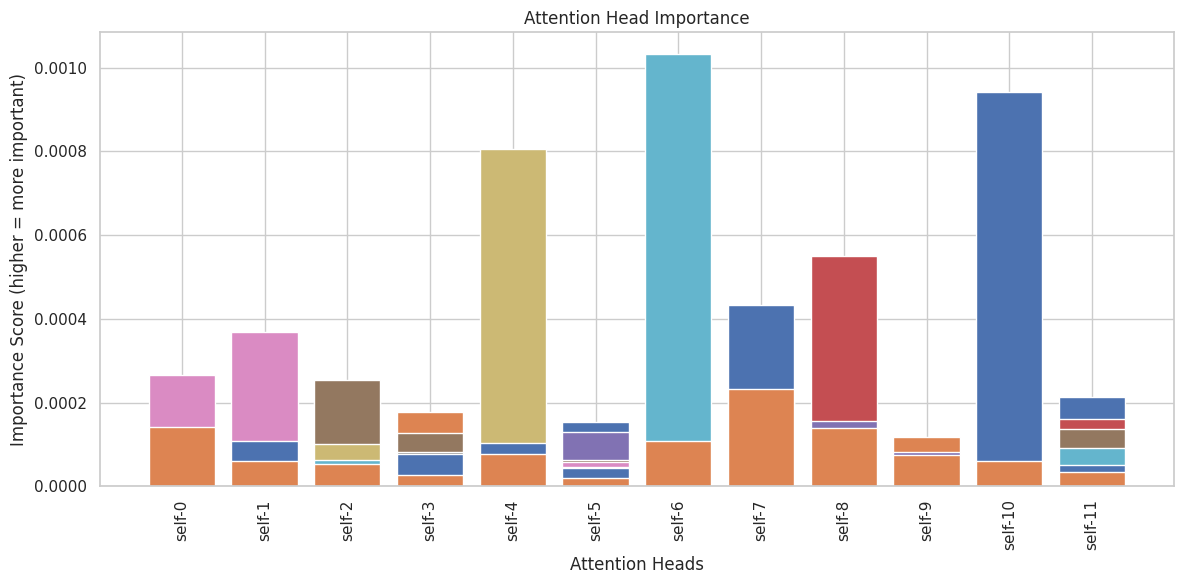

prune baby prune...43, 12
Pruning 43 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.at

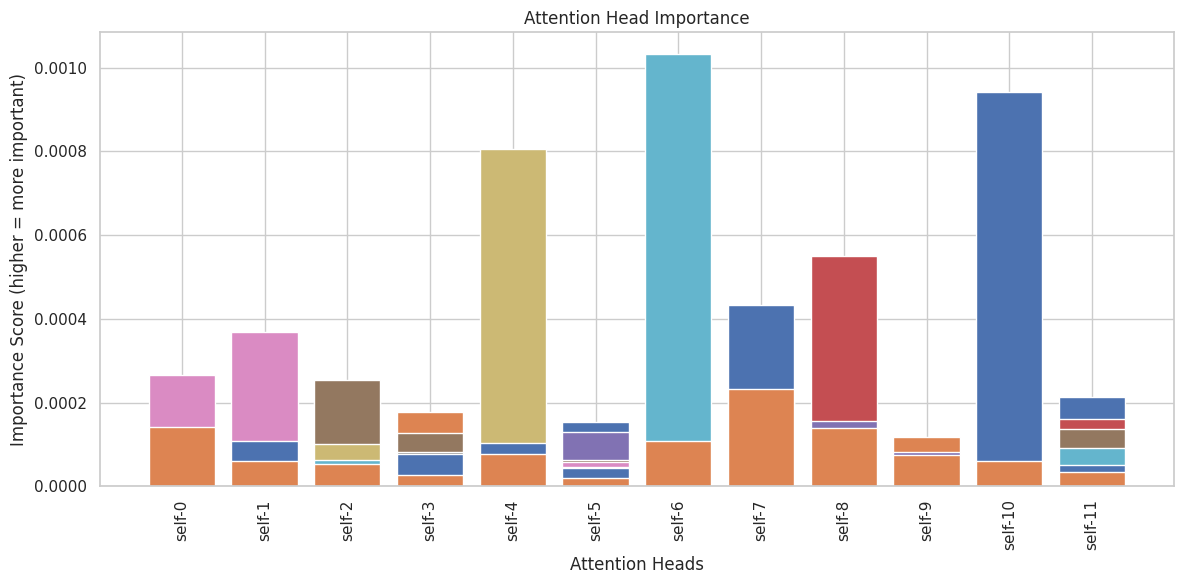

prune baby prune...57, 12
Pruning 57 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.at

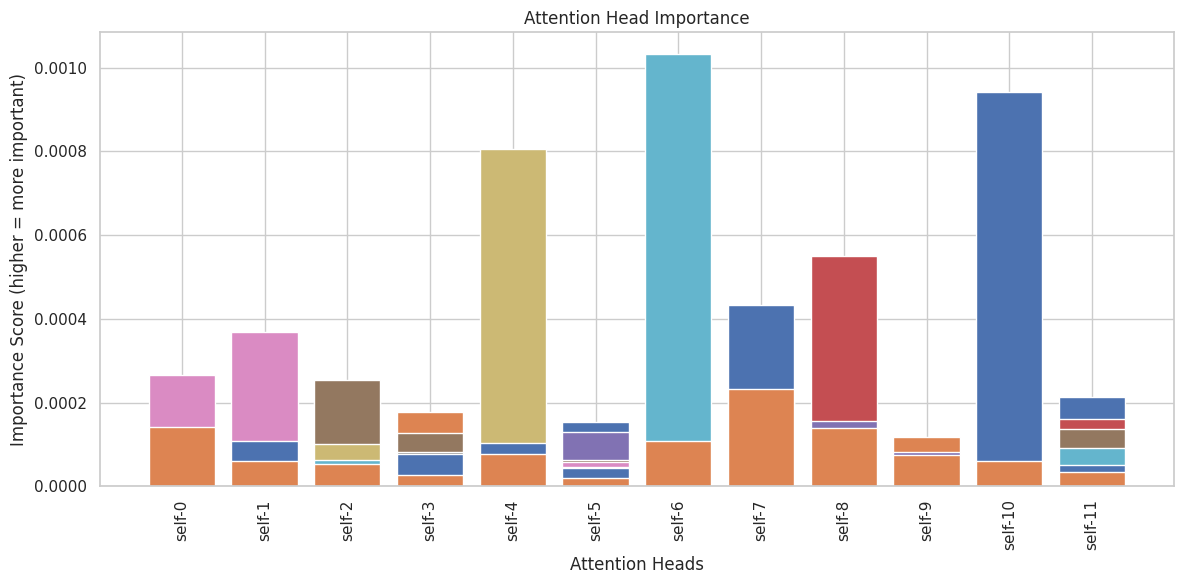

prune baby prune...72, 12
Pruning 72 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.at

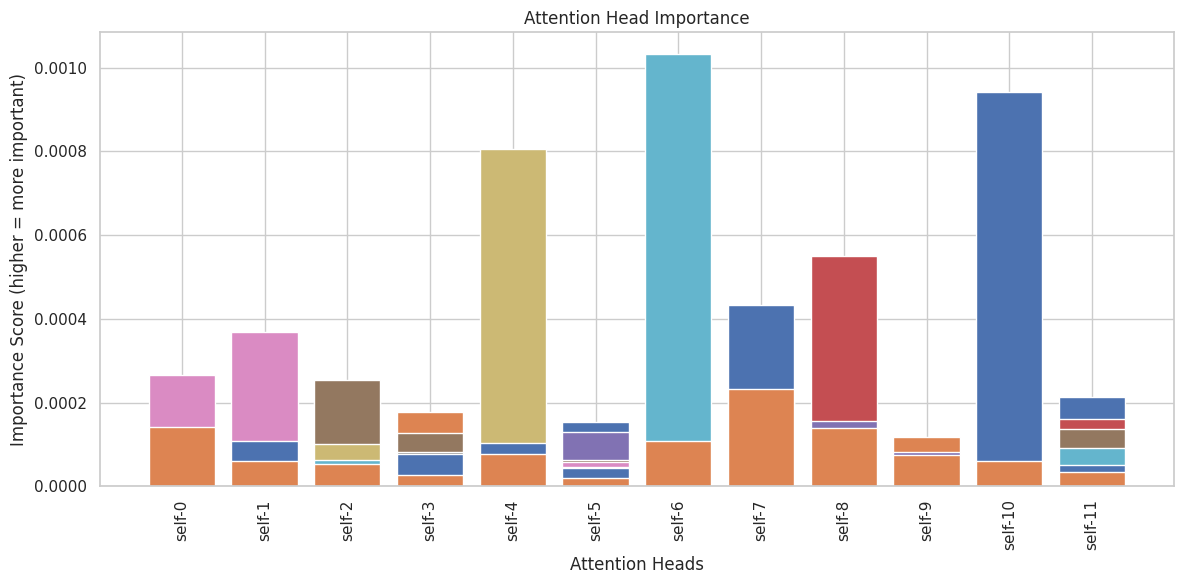

prune baby prune...86, 12
Pruning 86 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.at

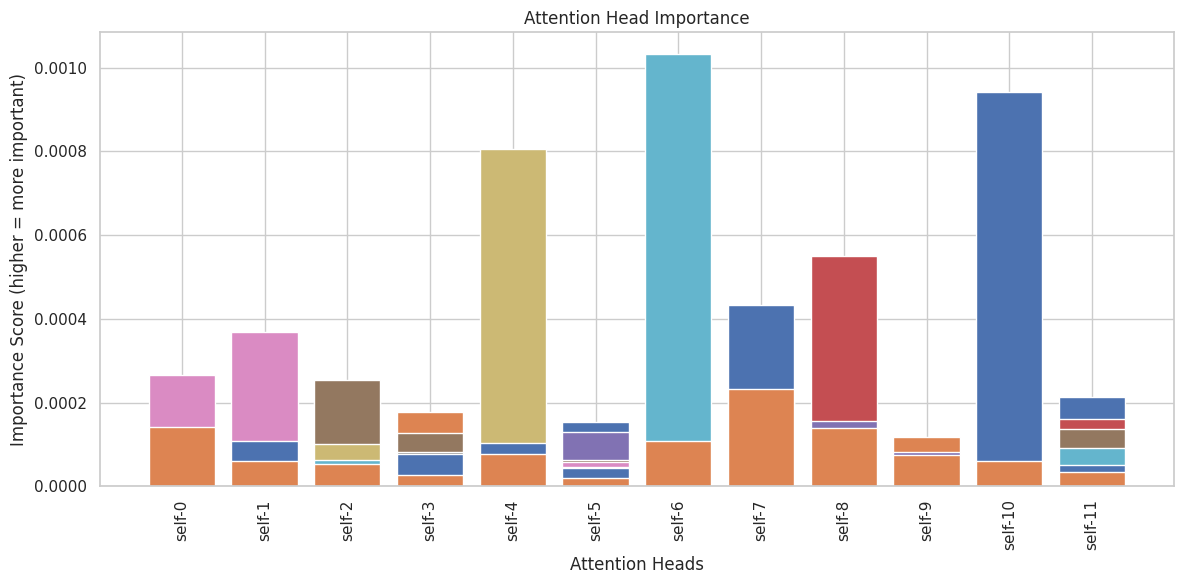

prune baby prune...100, 12
Pruning 100 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.

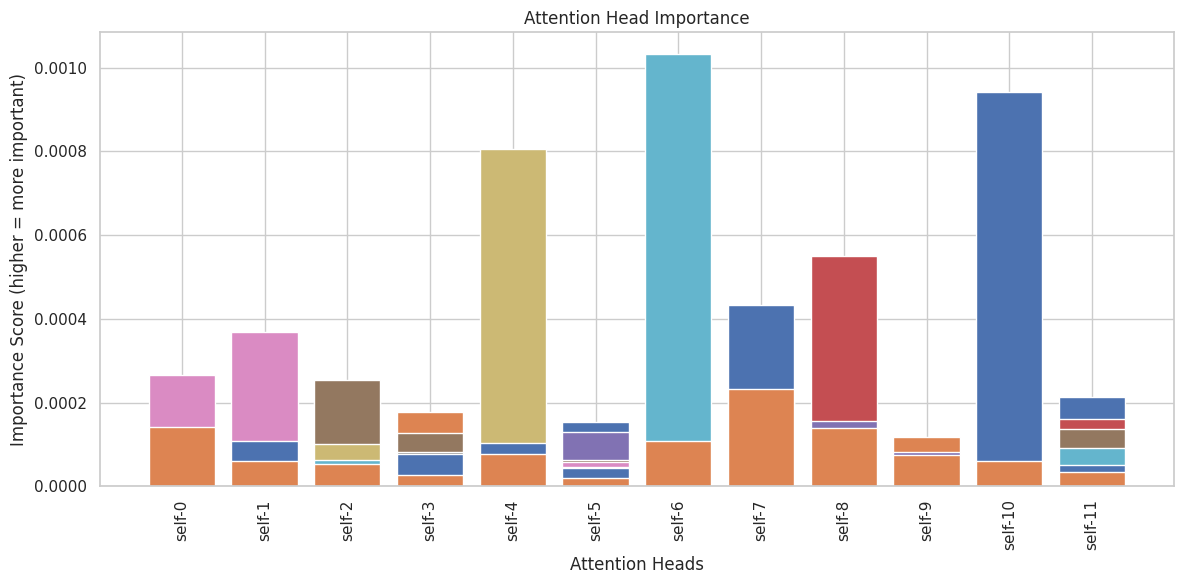

prune baby prune...115, 12
Pruning 115 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.

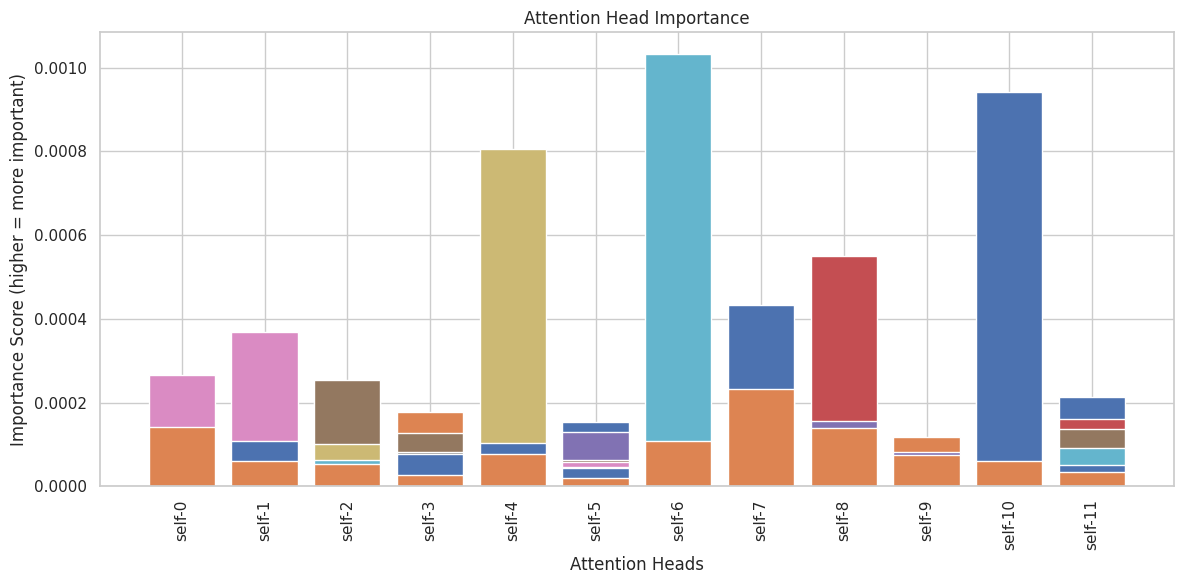

prune baby prune...116, 12
Pruning 116 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.

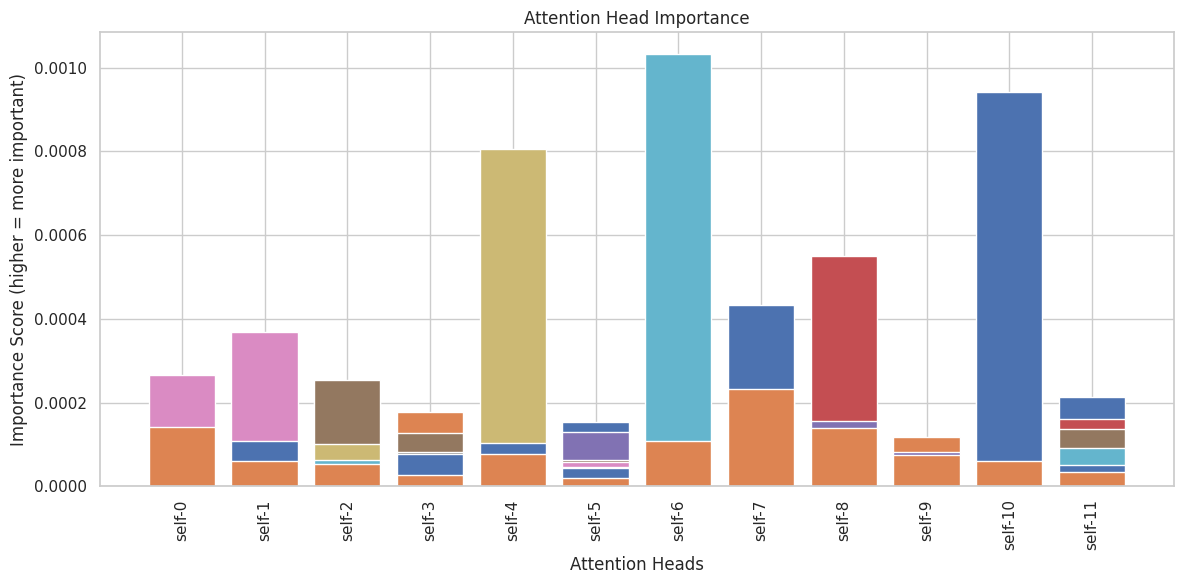

prune baby prune...118, 12
Pruning 118 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.

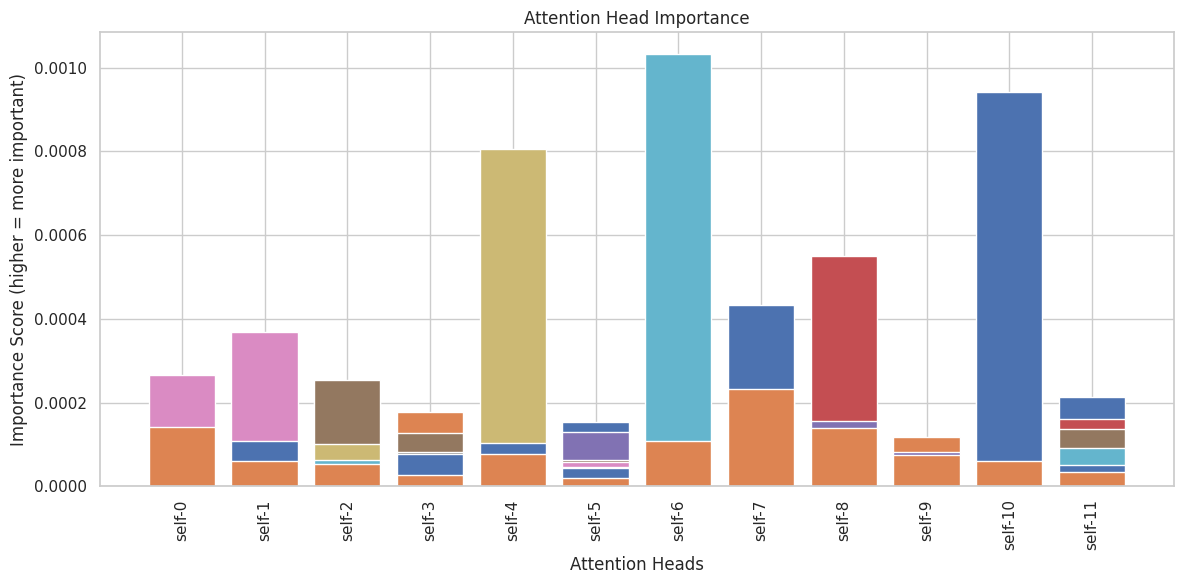

prune baby prune...119, 12
Pruning 119 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.

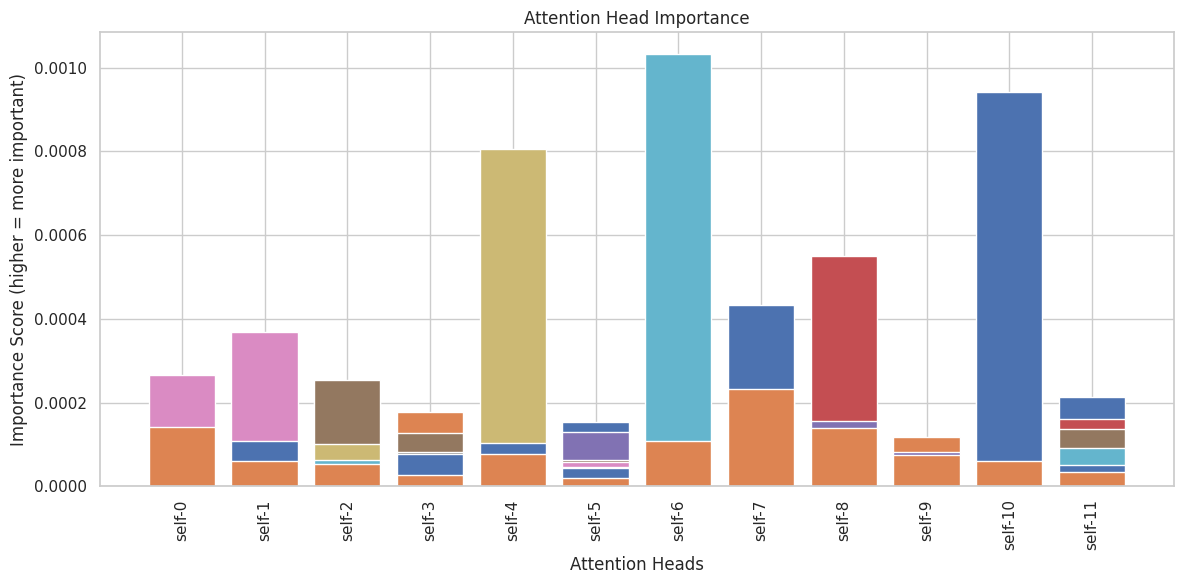

prune baby prune...120, 12
Pruning 120 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.

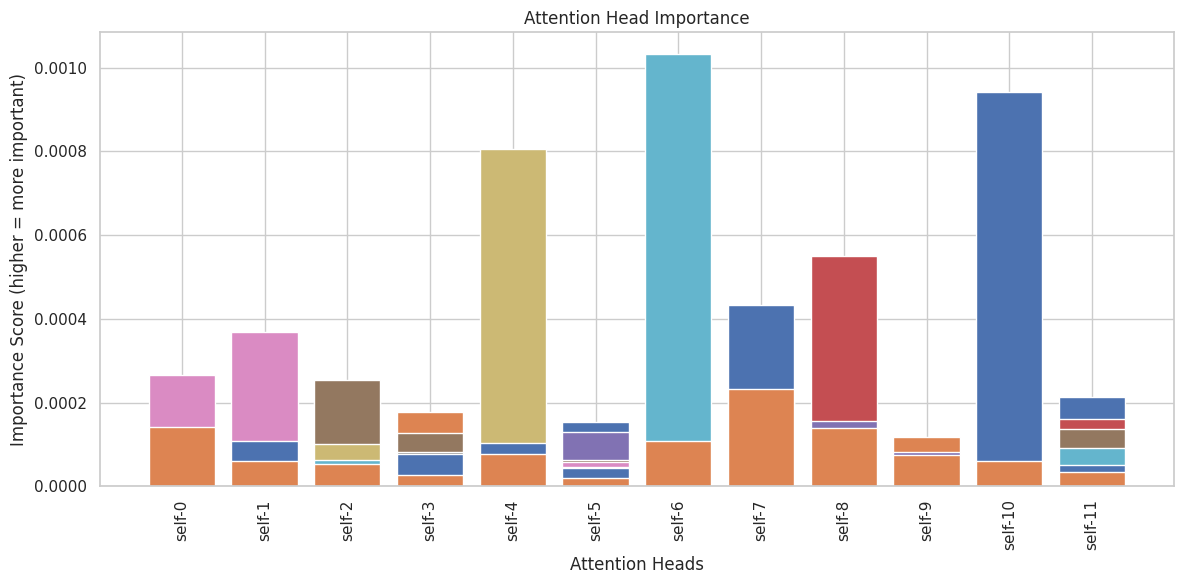

prune baby prune...122, 12
Pruning 122 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.

({'accuracy': 0.9994432071269488,
  'avg_latency_ms': 59.91996706059549,
  'model_size_mb': 477.74707794189453},
 [(0.1, 0.9991648106904232),
  (0.2, 0.9988864142538976),
  (0.3, 0.998608017817372),
  (0.4, 0.9983296213808464),
  (0.5, 0.9974944320712695),
  (0.6, 0.9741091314031181),
  (0.7, 0.9699331848552338),
  (0.8, 0.9688195991091314),
  (0.81, 0.969097995545657),
  (0.82, 0.9685412026726058),
  (0.83, 0.9685412026726058),
  (0.84, 0.9688195991091314),
  (0.85, 0.9671492204899778)],
 {'accuracy': 0.9671492204899778,
  'avg_latency_ms': 47.373910920809855,
  'model_size_mb': 387.65918731689453})

In [210]:
per_prune = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.81, 0.82, 0.83, 0.84, 0.85]
target_accuracy = 0.96
device = 'cuda'
original_metrics, acc_list, quant_acc_list, pruned_metrics, quant_metrics, pruned_model, quantized_dynamic_model = run_heads_prune_exp(head_importance, model, device, target_accuracy, per_prune, quantize=False)
original_metrics, acc_list, pruned_metrics

Evaluating model...
Test Loss: 0.004442478577167683, Test Accuracy: 0.9994432071269488
Model metrics:
- Accuracy: 0.9994
- Avg Latency: 59.82 ms
- Model Size: 477.75 MB
{'accuracy': 0.9994432071269488, 'avg_latency_ms': 59.81808426105871, 'model_size_mb': 477.74707794189453}


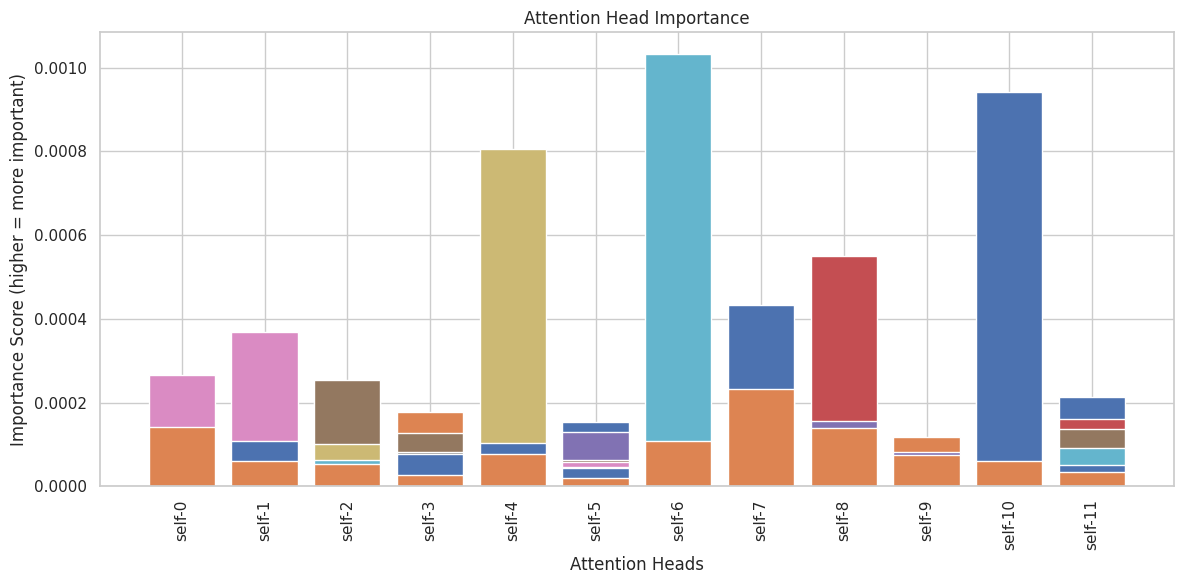

prune baby prune...14, 12
Pruning 14 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.at

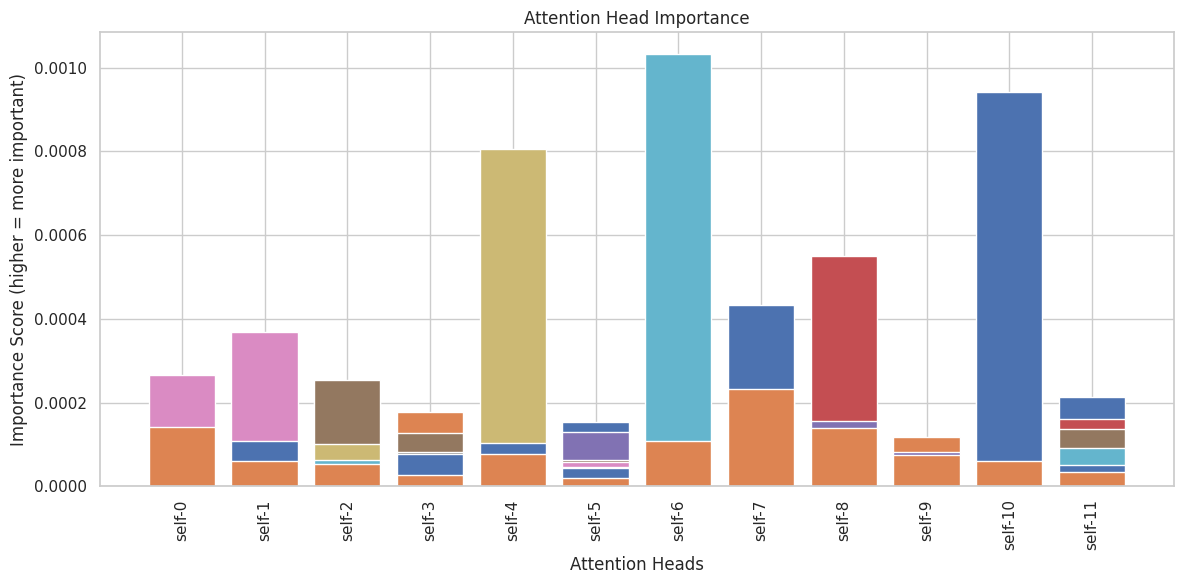

prune baby prune...28, 12
Pruning 28 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.at

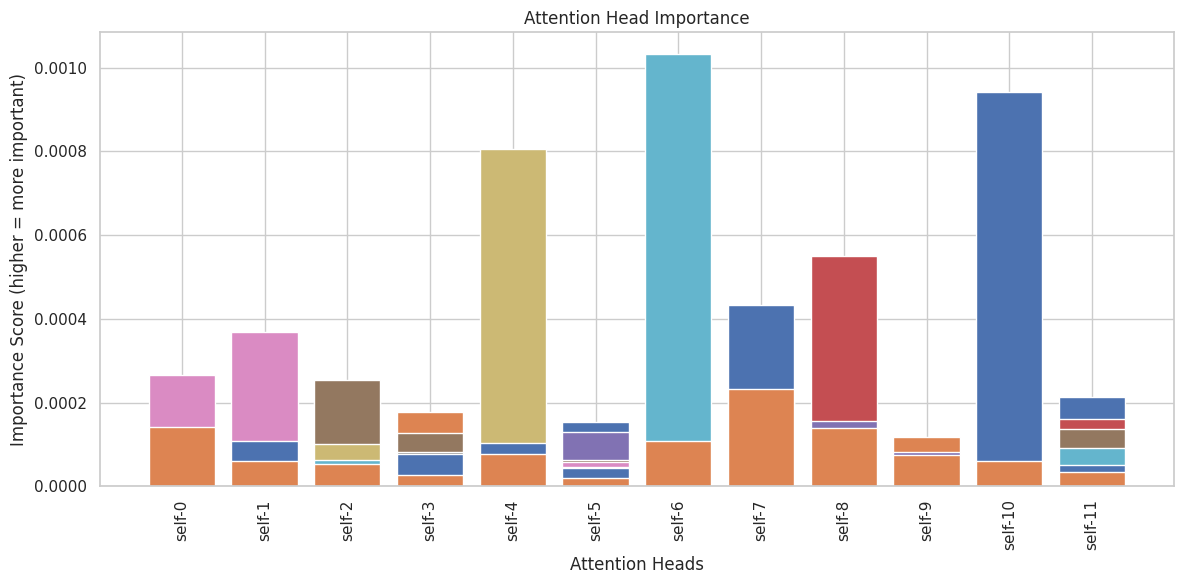

prune baby prune...43, 12
Pruning 43 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.at

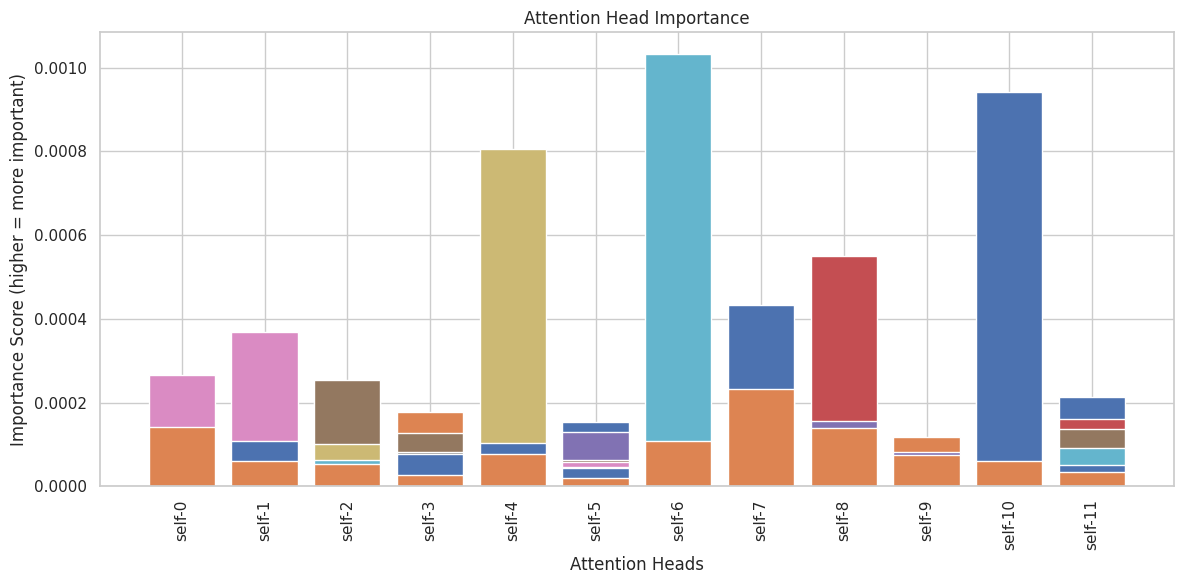

prune baby prune...57, 12
Pruning 57 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.at

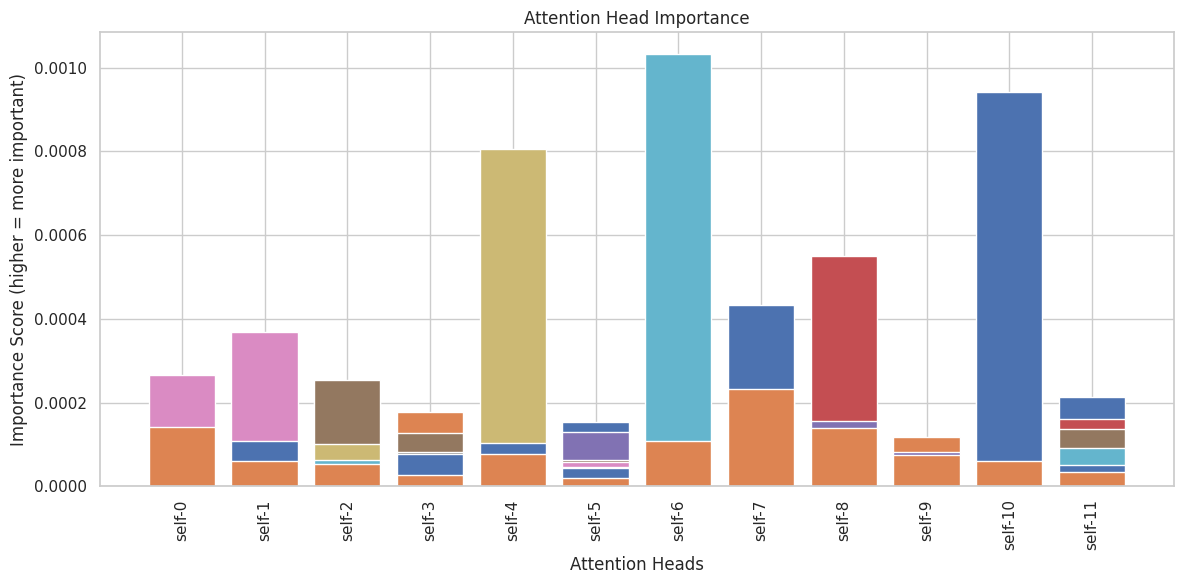

prune baby prune...72, 12
Pruning 72 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.at

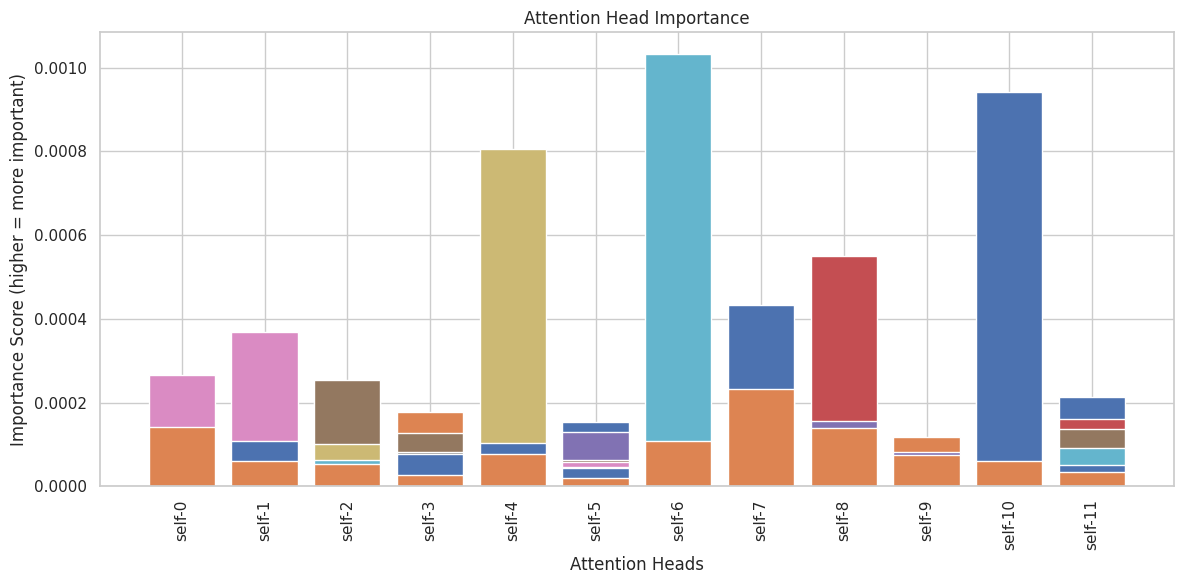

prune baby prune...86, 12
Pruning 86 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.at

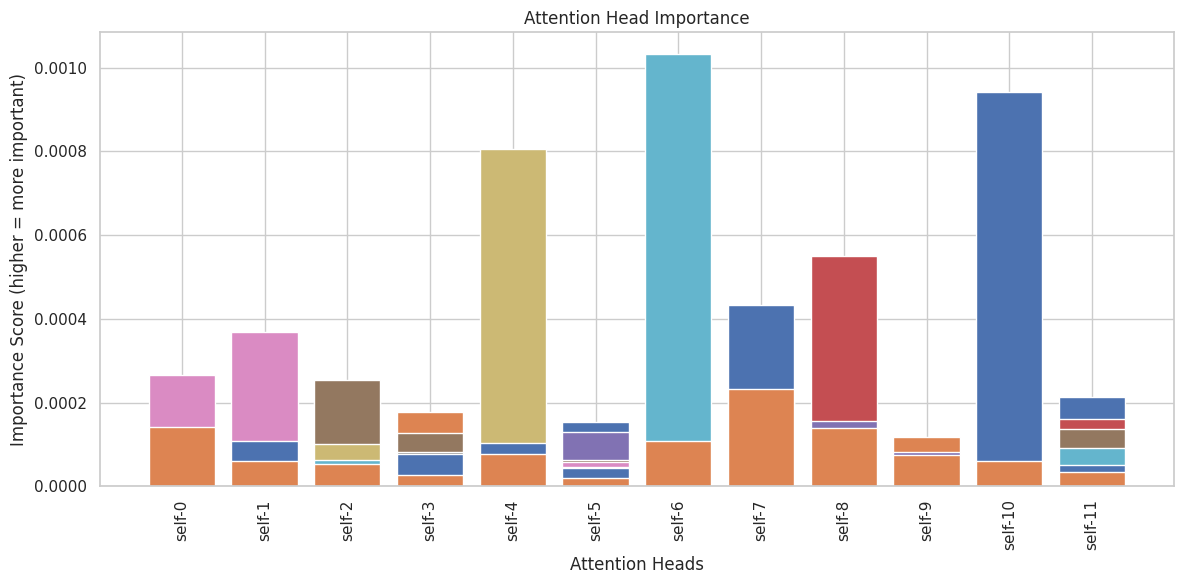

prune baby prune...100, 12
Pruning 100 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.

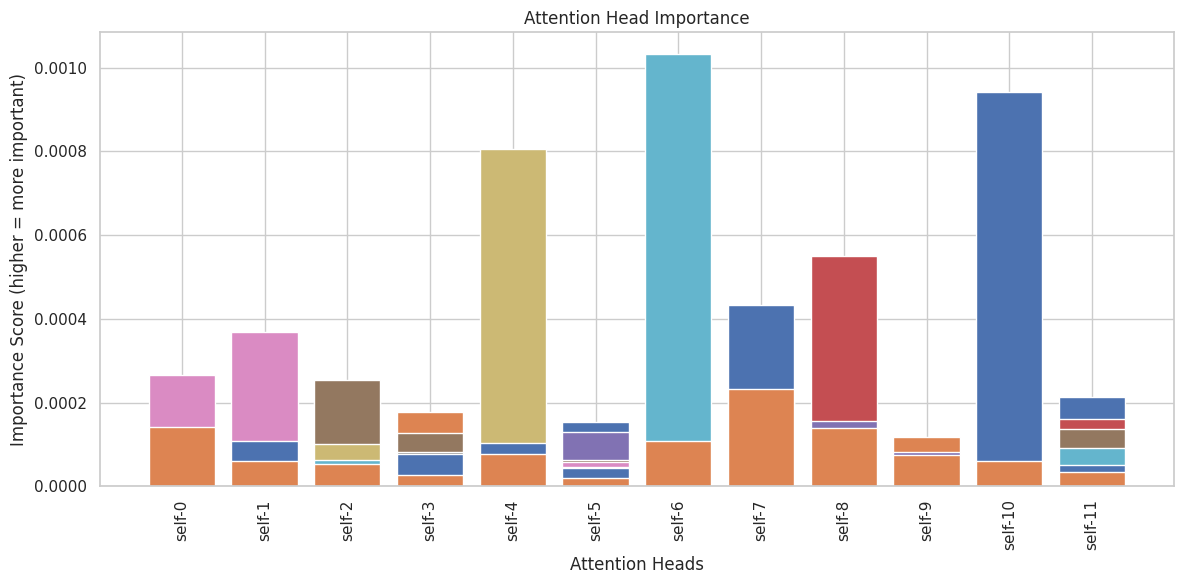

prune baby prune...115, 12
Pruning 115 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.

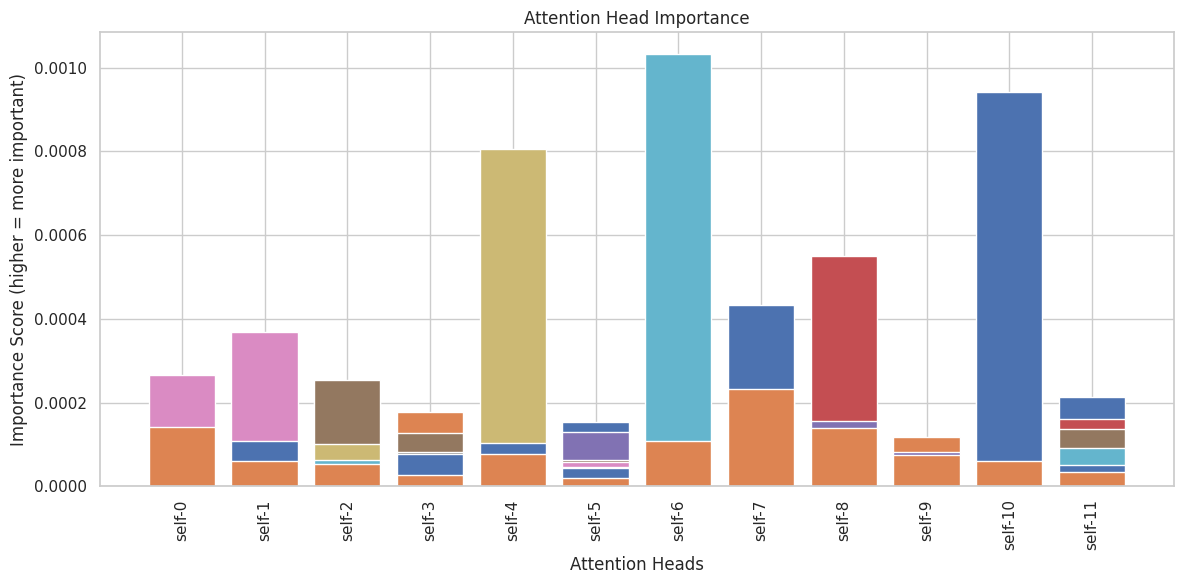

prune baby prune...116, 12
Pruning 116 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.

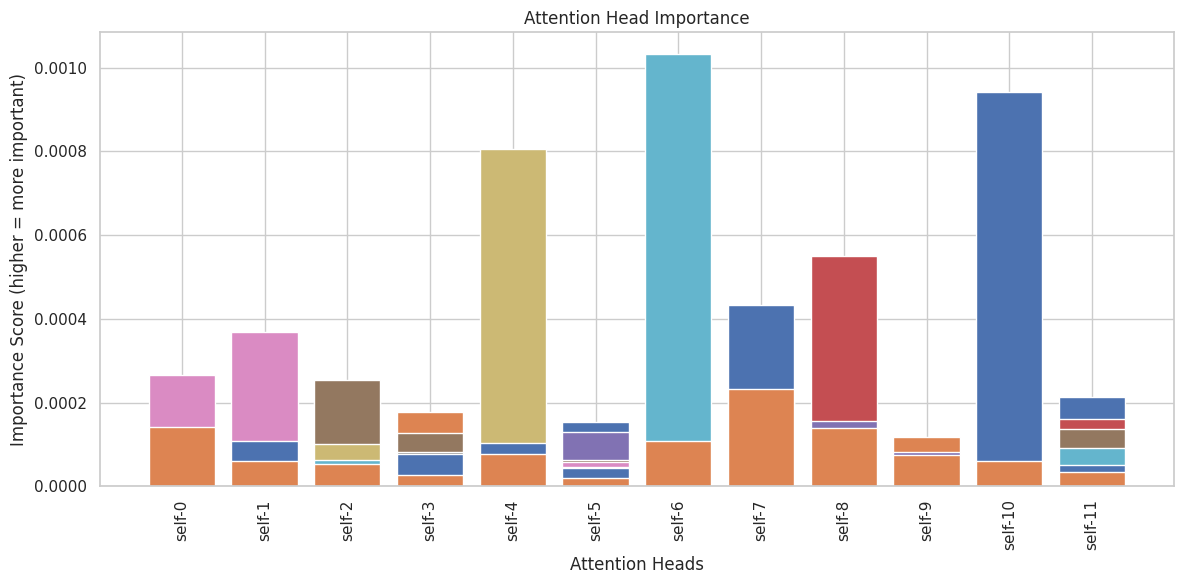

prune baby prune...118, 12
Pruning 118 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.

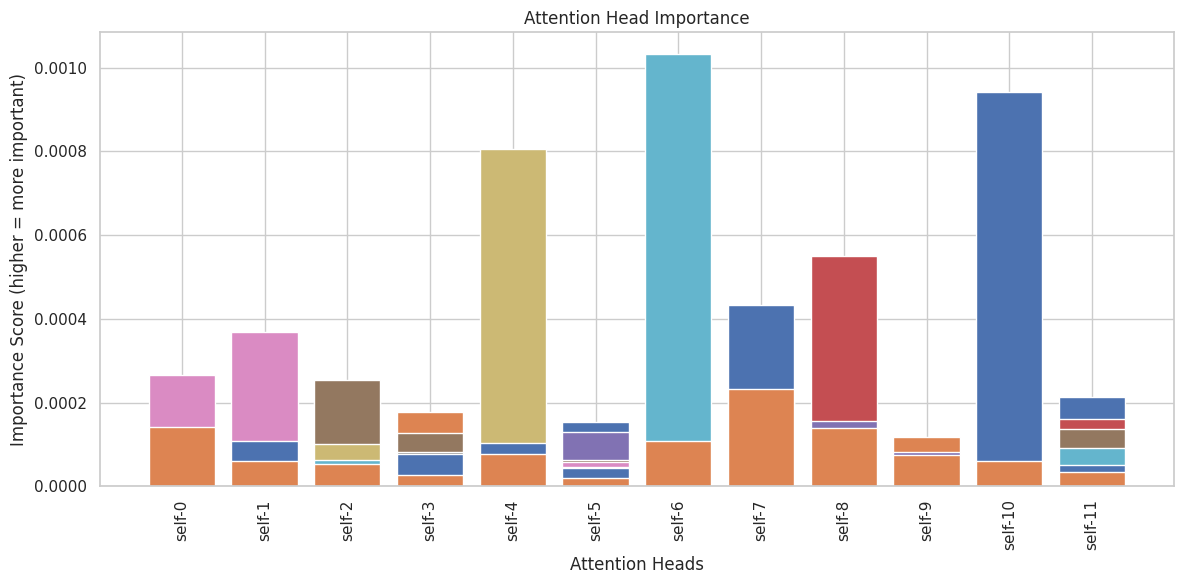

prune baby prune...119, 12
Pruning 119 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.

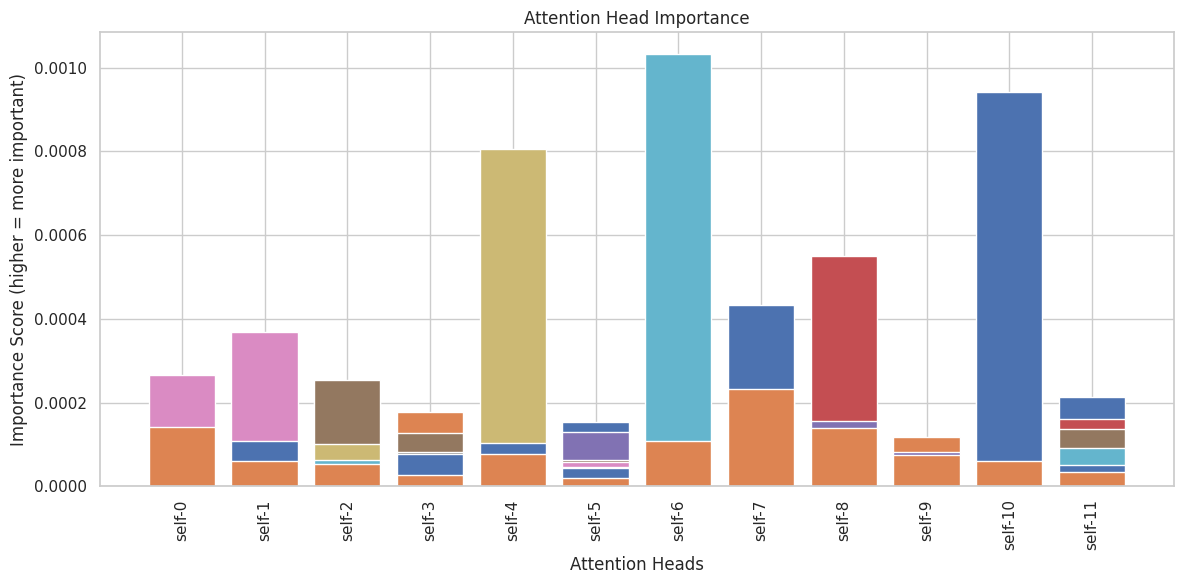

prune baby prune...120, 12
Pruning 120 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.

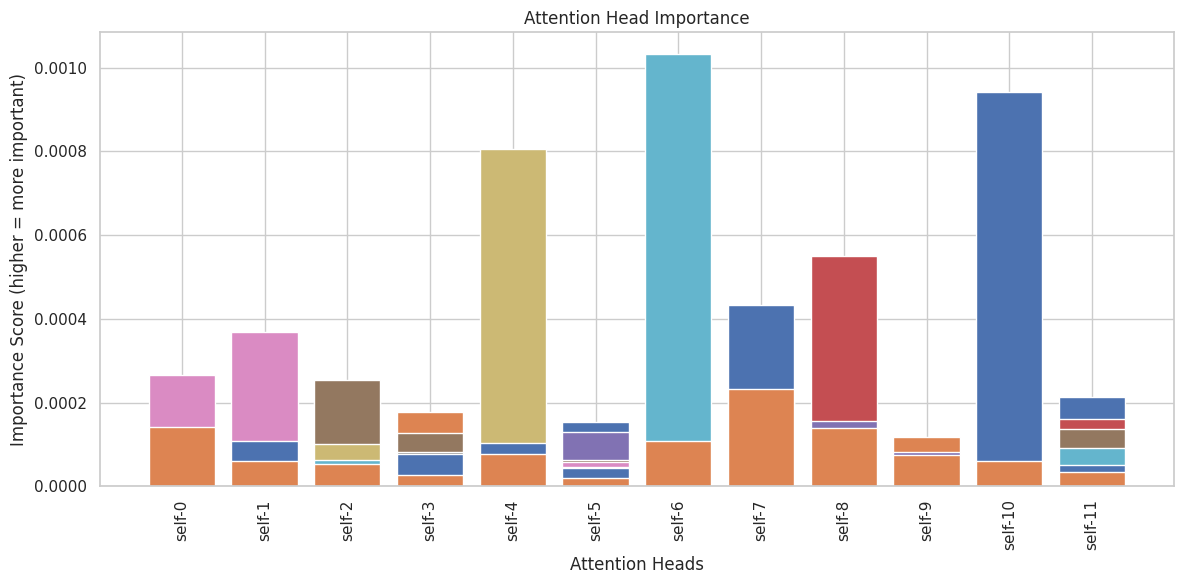

prune baby prune...122, 12
Pruning 122 heads with lowest importance scores
Pruning encoder.layer.6.attention.self head 3 (importance: 0.000016)
Pruning encoder.layer.7.attention.self head 1 (importance: 0.000016)
Pruning encoder.layer.6.attention.self head 4 (importance: 0.000016)
Pruning encoder.layer.1.attention.self head 0 (importance: 0.000018)
Pruning encoder.layer.11.attention.self head 5 (importance: 0.000020)
Pruning encoder.layer.9.attention.self head 8 (importance: 0.000021)
Pruning encoder.layer.10.attention.self head 2 (importance: 0.000021)
Pruning encoder.layer.8.attention.self head 10 (importance: 0.000022)
Pruning encoder.layer.10.attention.self head 9 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 5 (importance: 0.000023)
Pruning encoder.layer.8.attention.self head 6 (importance: 0.000023)
Pruning encoder.layer.6.attention.self head 9 (importance: 0.000024)
Pruning encoder.layer.8.attention.self head 8 (importance: 0.000024)
Pruning encoder.layer.3.

({'accuracy': 0.9994432071269488,
  'avg_latency_ms': 59.81808426105871,
  'model_size_mb': 477.74707794189453},
 [(0.1, 0.9991648106904232),
  (0.2, 0.9988864142538976),
  (0.3, 0.998608017817372),
  (0.4, 0.9983296213808464),
  (0.5, 0.9974944320712695),
  (0.6, 0.9741091314031181),
  (0.7, 0.9699331848552338),
  (0.8, 0.9688195991091314),
  (0.81, 0.969097995545657),
  (0.82, 0.9685412026726058),
  (0.83, 0.9685412026726058),
  (0.84, 0.9688195991091314),
  (0.85, 0.9671492204899778)],
 {'accuracy': 0.9671492204899778,
  'avg_latency_ms': 50.50634493870018,
  'model_size_mb': 387.65918731689453})

In [212]:
per_prune = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.81, 0.82, 0.83, 0.84, 0.85]
target_accuracy = 0.93
device = 'cuda'
original_metrics, acc_list, quant_acc_list, pruned_metrics, quant_metrics, pruned_q_model, quantized_dynamic_model = run_heads_prune_exp(head_importance, model, device, target_accuracy, per_prune, quantize=True)
original_metrics, acc_list, pruned_metrics

In [214]:
quantized_dynamic_model

custom_roberta(
  (basemodel): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0): RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): DynamicQuantizedLinear(in_features=768, out_features=448, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
              (key): DynamicQuantizedLinear(in_features=768, out_features=448, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
              (value): DynamicQuantizedLinear(in_features=768, out_features=448, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
              (dropout): Dropout(p=0.1, inplace=

In [215]:
quant_metrics = print_evaluate(quantized_dynamic_model, device='cpu')
print("Comparing quantized model metrics now....")
compare_prune_orig(quant_metrics, original_metrics)

Evaluating model...
Test Loss: 0.3014360581315174, Test Accuracy: 0.9323496659242761
Model metrics:
- Accuracy: 0.9323
- Avg Latency: 491.58 ms
- Model Size: 148.92 MB
Comparing quantized model metrics now....
Pruned model metrics:
- Accuracy: 0.9323
- Avg Latency: 491.58 ms
- Model Size: 148.92 MB

Comparison:
Accuracy change: -6.71%
Latency improvement: -721.79%
Size reduction: 68.83%


In [219]:
def save_checkpoint(model, model_file):
    ckpt_path = './content/data/ckpt/'
    if not os.path.exists(ckpt_path):
        os.mkdir(ckpt_path)
    ckpt_name = ckpt_path + model_file + '.pt'
    torch.save(model.state_dict(), ckpt_name)
    print(f'Saved Checkpoint : {ckpt_name}')
    return ckpt_name

In [221]:
ckpt_name = save_checkpoint(quantized_dynamic_model, "pruned_quant_model_roberta")

Saved Checkpoint : ./content/data/ckpt/pruned_quant_model_roberta.pt


In [226]:
torch.save(quantized_dynamic_model, ckpt_name)

In [227]:
# Load the entire pruned model object
new_model = torch.load(ckpt_name, weights_only=False)
new_model.eval()

custom_roberta(
  (basemodel): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0): RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): DynamicQuantizedLinear(in_features=768, out_features=448, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
              (key): DynamicQuantizedLinear(in_features=768, out_features=448, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
              (value): DynamicQuantizedLinear(in_features=768, out_features=448, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
              (dropout): Dropout(p=0.1, inplace=

In [228]:
quant_metrics = print_evaluate(new_model, device='cpu')
print("Comparing quantized model metrics now....")
compare_prune_orig(quant_metrics, original_metrics)

Evaluating model...
Test Loss: 0.3014360581315174, Test Accuracy: 0.9323496659242761
Model metrics:
- Accuracy: 0.9323
- Avg Latency: 345.13 ms
- Model Size: 148.92 MB
Comparing quantized model metrics now....
Pruned model metrics:
- Accuracy: 0.9323
- Avg Latency: 345.13 ms
- Model Size: 148.92 MB

Comparison:
Accuracy change: -6.71%
Latency improvement: -476.97%
Size reduction: 68.83%


#### Results: 
1) We saw you can remove upto 85% of heads without impacting model accuracy significantly
2) Model Quantization to 8 bits further reduces model size and cuts latency by upto 30% on CPU
3) DO NOT ever meddle with feed forward or mlp layers. it damages the model accuracy

### Do not execute following cells. FFN or MLP layers pruning damages the model's capabilities
This was done only to experiment and results were disastrous.
### DO NOT MEDDLE WITH FEED FORWARD OR MLP LAYERS

In [ ]:
import os
import time
import math
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
from transformers import AutoModelForCausalLM, AutoTokenizer

In [ ]:
MLP_PRUNE_FRAC = 0.034
MLP_PRUNE_FRAC

In [ ]:
def prune_mlp_rows_and_cols(model: nn.Module, prune_frac: float):
    """
    TODO:
      - Move model to CPU
      - For each layer in model.model.layers:
          • Zero out `prune_frac` of rows in gate_proj and up_proj
          • Zero out corresponding `prune_frac` of columns in down_proj
      - Remove pruning reparameterizations
    """
    # 1) Ensure we prune on CPU to avoid GPU OOM
    model.cpu()
    torch.cuda.empty_cache()
    n = 0

    # 2) Iterate through each decoder layer’s MLP
    for layer in model.basemodel.encoder.layer:
        n += 1
        #if n > 1:
        #    prune_frac=0.2
        #if n > 5:
        #    return model
        lin1 = layer.intermediate.dense   # [inner, hidden]
        #lin2   = layer.ffn.lin2    # [inner, hidden]
        
        # 2) Zero out rows in gate_proj and up_proj
        prune.ln_structured(
            lin1,
            name="weight",
            amount=prune_frac,
            n=1,
            dim=0,           # prune entire rows
            )
        prune.remove(lin1, "weight")

     # 3) Return the model (now with zeros in place)
    return model

In [ ]:
pruned_head_orig.basemodel.encoder.layer[0].intermediate.dense, pruned_head_orig.basemodel.encoder.layer[0].output.dense

In [ ]:
def rebuild_mlp_blocks(model):
    """
    TODO:
      - For each layer in model.model.layers:
          1) Identify kept neuron indices in gate_proj
          2) Construct new nn.Linear modules for gate_proj, up_proj, down_proj
             with reduced dimensions
          3) Copy over weights and biases
          4) Replace the old modules on the model
    """
    n = 0
    for layer in model.basemodel.encoder.layer:
        # original modules (still on CPU, dtype=original)
        n += 1
        #if n > 5:
        #    return model
        old_gate = layer.intermediate.dense
        #old_up   = layer.mlp.up_proj
        old_down = layer.output.dense

        # discover surviving rows in gate_proj
        Wg = old_gate.weight.data     # [inner_orig, hidden], dtype say torch.half
        keep_idx = (Wg.abs().sum(dim=1) != 0).nonzero(as_tuple=False).view(-1)
        inner_new = keep_idx.numel()
        hidden    = Wg.size(1)
        dtype     = Wg.dtype
        device    = Wg.device

        # helper to build a new Linear with the same dtype/device
        def make_linear(in_f, out_f, bias, old_weight, old_bias=None):
            nl = nn.Linear(in_f, out_f, bias=bias)
            # init in correct dtype & device
            nl.weight.data = old_weight.clone().to(device=device, dtype=dtype)
            if bias and old_bias is not None:
                nl.bias.data = old_bias.clone().to(device=device, dtype=dtype)
            return nl

        # rebuild gate_proj: hidden -> inner_new
        new_gate = make_linear(
            hidden, inner_new, 
            bias=(old_gate.bias is not None),
            old_weight=old_gate.weight.data[keep_idx],
            old_bias=old_gate.bias.data[keep_idx] if old_gate.bias is not None else None
        )

      # rebuild down_proj: inner_new -> hidden
        new_down = make_linear(
            inner_new, hidden,
            bias=(old_down.bias is not None),
            old_weight=old_down.weight.data[:, keep_idx],
            old_bias=old_down.bias.data if old_down.bias is not None else None
        )

        # swap in-place
        layer.intermediate.dense = new_gate
        layer.output.dense = new_down

    return model

In [ ]:
MLP_PRUNE_FRAC = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09]

In [ ]:
def run_ffn_prune_exp(pruned_head_orig, device, target_accuracy, MLP_PRUNE_FRAC):
    #MLP_PRUNE_FRAC = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09]
    original_metrics = print_evaluate(pruned_head_orig, device)
    print(original_metrics)
    acc_list = []
    for p in MLP_PRUNE_FRAC:
        pruned_model = copy.deepcopy(pruned_head_orig)
        prune_mlp_rows_and_cols(pruned_model, prune_frac=p)
        rebuild_mlp_blocks(pruned_model)
        print("Evaluating pruned model...")
        pruned_model = pruned_model.to(device)
        pruned_metrics = print_evaluate(pruned_model, device)
        acc_list.append((p,pruned_metrics['accuracy']))
        compare_prune_orig(pruned_metrics, original_metrics)
        if pruned_metrics['accuracy'] <= target_accuracy:
            return original_metrics, acc_list, pruned_metrics, pruned_model
    
    return original_metrics, acc_list, pruned_metrics, pruned_model

In [ ]:
target_accuracy = 0.93
pruned_head_orig_metrics, acc_list, pruned_metrics, pruned_model = run_ffn_prune_exp(pruned_head_orig, device, target_accuracy)

In [ ]:
pruned_head_orig_metrics, acc_list, pruned_metrics

In [ ]:
for layer in pruned_model.basemodel.encoder.layer :#[0].ffn
    print(layer.intermediate.dense)
    print(layer.output.dense)
    print("###########")

In [ ]:
#Let us run again so that we stay within target accuracy limits
MLP_PRUNE_FRAC = [0.01, 0.02]

In [ ]:
target_accuracy = 0.93
pruned_head_orig_metrics, acc_list, pruned_metrics, pruned_model = run_ffn_prune_exp(pruned_head_orig, device, target_accuracy, MLP_PRUNE_FRAC)

In [ ]:
pruned_head_orig_metrics, acc_list, pruned_metrics

In [ ]:
for layer in pruned_model.basemodel.encoder.layer :#[0].ffn
    print(layer.intermediate.dense)
    print(layer.output.dense)
    print("###########")